# Baseline Model Operation - EM + 拟牛顿法版

本 notebook 从变量准备产物读取扩展后的标准化输入，先运行 EM handoff，再用 L-BFGS-B 做拟牛顿法细化。


## 0. 读取变量准备产物


In [24]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

plt.rcParams["axes.unicode_minus"] = False
for font_name in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS"]:
    current_fonts = plt.rcParams.get("font.sans-serif", [])
    if font_name not in current_fonts:
        plt.rcParams["font.sans-serif"] = [font_name] + current_fonts

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "AGENTS.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "AGENTS.md").exists():
            PROJECT_ROOT = parent
            break

MONTHLY_MODEL_DIR = "月频模型"
INTERMEDIATE_DIR_NAME = "模型流程中产物"
OUTPUT_DIR = PROJECT_ROOT / MONTHLY_MODEL_DIR / "processed"
INTERMEDIATE_DIR = PROJECT_ROOT / MONTHLY_MODEL_DIR / INTERMEDIATE_DIR_NAME

TRAIN_START = pd.Period("2005-01", freq="M")
TRAIN_END = pd.Period("2014-12", freq="M")
TRAIN_WINDOW_TAG = f"{TRAIN_START.year:04d}{TRAIN_START.month:02d}_{TRAIN_END.year:04d}{TRAIN_END.month:02d}"
PREP_META_PATH = OUTPUT_DIR / f"baseline_variable_preparation_meta_{TRAIN_WINDOW_TAG}.json"
if not PREP_META_PATH.exists():
    raise FileNotFoundError(f"Run the variable preparation notebook first; missing metadata: {PREP_META_PATH}")

prep_meta = json.loads(PREP_META_PATH.read_text(encoding="utf-8"))
TIME_COL = prep_meta["time_col"]
GDP_COL = prep_meta["gdp_col"]
MODEL_COLS_CANDIDATE = prep_meta["model_cols"]
PCA_INIT_COLS = prep_meta.get("pca_init_cols", [col for col in MODEL_COLS_CANDIDATE if col != prep_meta["gdp_col"]])
MODEL_COLS = prep_meta.get("recommended_model_cols_single_factor", [prep_meta["gdp_col"]] + PCA_INIT_COLS)
BASE_MODEL_COLS = prep_meta.get("base_model_cols", MODEL_COLS_CANDIDATE)
TRAIN_START = pd.Period(prep_meta["train_start"], freq="M")
TRAIN_END = pd.Period(prep_meta["train_end"], freq="M")
TRAIN_WINDOW_TAG = prep_meta["train_window_tag"]

prepared_panel_path = Path(prep_meta["prepared_model_panel_path"])
standardized_input_path = Path(prep_meta["standardized_input_path"])
standardization_params_path = Path(prep_meta["standardization_params_path"])
winsor_limits_path = Path(prep_meta["winsor_limits_path"])

model_df_full = pd.read_csv(prepared_panel_path, encoding="utf-8-sig")
model_df_full[TIME_COL] = pd.PeriodIndex(model_df_full[TIME_COL], freq="M")
model_df_full = model_df_full.set_index(TIME_COL).sort_index()
model_df = model_df_full.loc[TRAIN_START:TRAIN_END, MODEL_COLS].copy()
train_df = model_df.copy()

z_model_df = pd.read_csv(standardized_input_path, encoding="utf-8-sig")
z_model_df[TIME_COL] = pd.PeriodIndex(z_model_df[TIME_COL], freq="M")
z_model_df = z_model_df.set_index(TIME_COL).sort_index()
z_train_df = z_model_df.copy()

standardization_params = pd.read_csv(standardization_params_path, encoding="utf-8-sig").set_index("variable")
standardization_params["invalid_for_standardization"] = standardization_params["invalid_for_standardization"].astype(bool)
mean_train = standardization_params["mean_train"].astype(float)
std_train = standardization_params["std_train"].astype(float)
std_train_safe = std_train.mask(std_train == 0)
gdp_mean_train = float(mean_train.loc[GDP_COL])
gdp_std_train = float(std_train.loc[GDP_COL])
winsor_limits = pd.read_csv(winsor_limits_path, encoding="utf-8-sig")

RUN_EM = True
EM_MAX_ITER = 150
FACTOR_AR_ORDER = 15
RELATIVE_LOGLIKE_TOL = 1e-6
EM_TO_QN_REL_LOGLIKE_TOL = 1e-5
RUN_QUASI_NEWTON = True
QN_FTOL = 1e-6
QN_STOP_REL_CHANGE = 1e-5
QN_STOP_PATIENCE = 5

model_variant_tag = prep_meta.get("model_variant_tag", "expandedvars") + "_singlefactor"
operation_suffix = 'em_qn'
ESTIMATION_RESULT_DIR = INTERMEDIATE_DIR / '8-模型估计结果'
ESTIMATION_RESULT_DIR.mkdir(parents=True, exist_ok=True)
EM_CACHE_PREFIX = f"{model_variant_tag}_{operation_suffix}_{TRAIN_WINDOW_TAG}_ar{FACTOR_AR_ORDER}_swpca_balanced_noclip_paperll_rel1e6"
EM_META_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_meta.json"
EM_LOADING_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_loading.csv"
EM_H_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_h.csv"
EM_HISTORY_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_history.csv"
EM_SMOOTHED_STATE_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_smoothed_state.csv"
EM_FILTERED_STATE_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_filtered_state.csv"

print(f"Loaded variable preparation metadata: {PREP_META_PATH}")
print(f"Training window: {TRAIN_START} to {TRAIN_END}")
print(f"Model variables: {len(MODEL_COLS)}; seasonally adjusted additions: {len(prep_meta.get('seasonally_adjusted_cols', []))}")
print(f"EM cache prefix: {EM_CACHE_PREFIX}")


Loaded variable preparation metadata: C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\processed\baseline_variable_preparation_meta_200501_201412.json
Training window: 2005-01 to 2014-12
Model variables: 9; seasonally adjusted additions: 3
EM cache prefix: expandedvars_singlefactor_em_qn_200501_201412_ar15_swpca_balanced_noclip_paperll_rel1e6


## 6. 定义 Harvey 递推累加器与高阶动态状态

本节解决混频问题：潜在经济状态是月度的，但 GDP 是季度观测。设月度潜在经济状态为 $\alpha_t$。季度 GDP 不应只对应季度末一个月，而应对应该季度三个月经济状态的合成，因此引入季度累加器 $S_t$。

状态向量定义为：

$$
\xi_t =
\begin{bmatrix}
\alpha_t \\
\alpha_{t-1} \\
\alpha_{t-2} \\
\vdots \\
\alpha_{t-p+1} \\
S_t
\end{bmatrix}.
$$

其中 $p$ 是共同因子的 AR 阶数，$S_t$ 表示本季度从季度初到当前月累计的月度经济状态。

月度潜在因子服从 AR($p$)：

$$
\alpha_t =
\rho_1 \alpha_{t-1}
+ \rho_2 \alpha_{t-2}
+ \cdots
+ \rho_p \alpha_{t-p}
+ \eta_t.
$$

季度累加器定义为：

$$
S_t = s_t S_{t-1} + \alpha_t,
$$

其中：

$$
s_t =
\begin{cases}
0, & t \in \{1,4,7,10\}, \\
1, & t \in \{2,3,5,6,8,9,11,12\}.
\end{cases}
$$

也就是说，季度第一个月重新开始累加，季度内第二、三个月继续累加：

$$
\begin{aligned}
S_{q,1} &= \alpha_{q,1}, \\
S_{q,2} &= \alpha_{q,1} + \alpha_{q,2}, \\
S_{q,3} &= \alpha_{q,1} + \alpha_{q,2} + \alpha_{q,3}.
\end{aligned}
$$

GDP 只在季度末月份观测，因此季度末 GDP 观测方程为：

$$
y^{GDP}_t = \lambda_{GDP} S_t + \varepsilon^{GDP}_t,
\qquad t \in \{3,6,9,12\}.
$$

非季度末月份 GDP 不进入观测方程。

状态转移可写为：

$$
\xi_t = F_t \xi_{t-1} + R\eta_t,
$$

其中：

$$
F_t =
\begin{bmatrix}
\rho_1 & \rho_2 & \cdots & \rho_{p-1} & \rho_p & 0 \\
1 & 0 & \cdots & 0 & 0 & 0 \\
0 & 1 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & \cdots & 1 & 0 & 0 \\
\rho_1 & \rho_2 & \cdots & \rho_{p-1} & \rho_p & s_t
\end{bmatrix},
\qquad
R =
\begin{bmatrix}
1 \\
0 \\
\vdots \\
0 \\
1
\end{bmatrix}.
$$

矩阵 $F_t$ 的最后一行对应累加器更新。由于 $S_t$ 包含当月 $\alpha_t$，而 $\alpha_t$ 又由过去 $p$ 期因子预测，因此最后一行也包含 $\rho_1,\ldots,\rho_p$。



In [25]:
AR_PARAM_NAMES = [f"rho_{lag}" for lag in range(1, FACTOR_AR_ORDER + 1)]
ALPHA_STATE_NAMES = ["alpha_t"] + [f"alpha_lag{lag}" for lag in range(1, FACTOR_AR_ORDER)]
STATE_NAMES = ALPHA_STATE_NAMES + ["S_t"]
GDP_OBSERVATION_WEIGHTS = pd.Series(
    [0.0] * (len(STATE_NAMES) - 1) + [1.0],
    index=STATE_NAMES,
    name="gdp_observation_weight",
)
QUARTER_END_MONTHS = [3, 6, 9, 12]
QUARTER_START_MONTHS = [1, 4, 7, 10]


def is_quarter_start_month(month: pd.Period) -> bool:
    return month.month in QUARTER_START_MONTHS


def is_quarter_end_month(month: pd.Period) -> bool:
    return month.month in QUARTER_END_MONTHS


def accumulator_switch_for_month(month: pd.Period) -> float:
    """s_t in S_t = s_t * S_{t-1} + alpha_t."""
    return 0.0 if is_quarter_start_month(month) else 1.0


def ensure_ar_params(ar_params) -> pd.Series:
    """把 AR(p) 参数整理为 rho_1...rho_p 的 Series。"""
    if isinstance(ar_params, pd.Series):
        values = ar_params.reindex(AR_PARAM_NAMES).astype(float)
    else:
        values = pd.Series(list(np.asarray(ar_params, dtype=float).ravel()), index=AR_PARAM_NAMES, dtype=float)
    if len(values) != FACTOR_AR_ORDER or values.isna().any():
        raise ValueError(f"AR 参数必须包含 {FACTOR_AR_ORDER} 个有效系数：{AR_PARAM_NAMES}")
    return values


def harvey_transition_matrix(ar_params, month: pd.Period) -> pd.DataFrame:
    """Transition matrix for xi_t = [alpha_t, alpha_{t-1}, ..., S_t]'."""
    ar_params = ensure_ar_params(ar_params)
    s_t = accumulator_switch_for_month(month)
    matrix = pd.DataFrame(0.0, index=STATE_NAMES, columns=STATE_NAMES)

    # alpha_t = rho_1 alpha_{t-1} + ... + rho_p alpha_{t-p} + eta_t
    matrix.loc["alpha_t", ALPHA_STATE_NAMES] = ar_params.to_numpy(dtype=float)

    # companion shift: alpha_lag1,t = alpha_{t-1}; alpha_lag2,t = alpha_{t-2}; ...
    for lag in range(1, FACTOR_AR_ORDER):
        matrix.loc[f"alpha_lag{lag}", ALPHA_STATE_NAMES[lag - 1]] = 1.0

    # S_t = s_t * S_{t-1} + alpha_t
    matrix.loc["S_t", ALPHA_STATE_NAMES] = ar_params.to_numpy(dtype=float)
    matrix.loc["S_t", "S_t"] = s_t

    if matrix.shape != (len(STATE_NAMES), len(STATE_NAMES)):
        raise ValueError(f"F_t 维度异常：{matrix.shape}，期望 {(len(STATE_NAMES), len(STATE_NAMES))}")
    return matrix


def harvey_shock_loading(R: float = 1.0) -> pd.Series:
    """Shock loading in the recursive accumulator state equation."""
    shock = pd.Series(0.0, index=STATE_NAMES, name="shock_loading")
    shock.loc["alpha_t"] = R
    shock.loc["S_t"] = R
    return shock


def gdp_observation_row_for_month(month: pd.Period) -> pd.Series:
    """GDP observation row for xi_t = [alpha_t, alpha lags, S_t]'."""
    if is_quarter_end_month(month):
        return GDP_OBSERVATION_WEIGHTS.copy()
    return pd.Series(0.0, index=STATE_NAMES, name="gdp_observation_weight")


dummy_ar_params = pd.Series(
    [0.7] + [0.0] * (FACTOR_AR_ORDER - 1),
    index=AR_PARAM_NAMES,
    name="dummy_ar_params",
)

gdp_accumulator_design = pd.DataFrame(index=z_model_df.index)
gdp_accumulator_design["quarter_start"] = [is_quarter_start_month(m) for m in gdp_accumulator_design.index]
gdp_accumulator_design["quarter_end"] = [is_quarter_end_month(m) for m in gdp_accumulator_design.index]
gdp_accumulator_design["s_t"] = [accumulator_switch_for_month(m) for m in gdp_accumulator_design.index]
gdp_accumulator_design["gdp_observed_in_panel"] = z_model_df[GDP_COL].notna()
for state_name in STATE_NAMES:
    gdp_accumulator_design[f"Z_GDP_{state_name}"] = [gdp_observation_row_for_month(m).loc[state_name] for m in gdp_accumulator_design.index]

display_summary_months = gdp_accumulator_design.loc[TRAIN_START:TRAIN_START + 11].copy()

print(f"FACTOR_AR_ORDER = {FACTOR_AR_ORDER}")



FACTOR_AR_ORDER = 15


## 7. 定义观测方程结构

本节只定义观测变量如何连接到状态向量，不估计参数。

状态向量为：

$$
\xi_t =
\begin{bmatrix}
\alpha_t \\
S_t
\end{bmatrix}
$$

GDP 在季度末观测累加器：

$$
GDP_t =
\begin{bmatrix}
0 & 1
\end{bmatrix}
\xi_t + \varepsilon_{GDP,t}
$$

月度宏观变量加载到月度潜在状态：

$$
x_{i,t} =
\begin{bmatrix}
\lambda_i & 0
\end{bmatrix}
\xi_t + \varepsilon_{i,t}
$$

当月缺失的变量不进入当期 Kalman 观测方程。









In [26]:
valid_standardization_mask = ~standardization_params["invalid_for_standardization"]
model_cols_valid = standardization_params.index[valid_standardization_mask].tolist()

if GDP_COL not in model_cols_valid:
    raise ValueError(f"GDP 目标变量无法进入模型，请检查标准化参数: {GDP_COL}")

monthly_model_cols = [col for col in model_cols_valid if col != GDP_COL]
excluded_model_cols = [col for col in MODEL_COLS if col not in model_cols_valid]

# 这里只定义结构；lambda_i 后续由 PCA / OLS 初始化得到。先用 1.0 占位，方便展示观测矩阵形状。
loading_placeholder = pd.Series(1.0, index=monthly_model_cols, name="lambda_placeholder")


def build_observation_matrix_full(month: pd.Period, monthly_loadings: pd.Series) -> pd.DataFrame:
    """构造当月完整观测矩阵 Z_full_t，行顺序为 GDP + 月度变量。"""
    rows = {}
    rows[GDP_COL] = gdp_observation_row_for_month(month)
    for col in monthly_model_cols:
        row = pd.Series(0.0, index=STATE_NAMES)
        row.loc["alpha_t"] = monthly_loadings.loc[col]
        rows[col] = row
    return pd.DataFrame.from_dict(rows, orient="index", columns=STATE_NAMES)


def observed_mask_for_row(y_row: pd.Series) -> pd.Series:
    """根据当月观测值是否为 NaN，判断哪些变量进入当期观测方程。"""
    return y_row.notna()


def build_observed_system_for_month(month: pd.Period, y_panel: pd.DataFrame, monthly_loadings: pd.Series):
    """返回当月 y_obs、Z_obs 和 observed_mask。"""
    y_t = y_panel.loc[month, model_cols_valid]
    observed_mask_t = observed_mask_for_row(y_t)
    Z_full_t = build_observation_matrix_full(month, monthly_loadings)
    y_obs_t = y_t.loc[observed_mask_t]
    Z_obs_t = Z_full_t.loc[observed_mask_t]
    return y_obs_t, Z_obs_t, observed_mask_t

# 示例展示训练窗口内第一个 GDP 有观测的季度末月份。
example_month = z_model_df[GDP_COL].first_valid_index()
y_obs_example, Z_obs_example, observed_mask_example = build_observed_system_for_month(
    example_month,
    z_model_df,
    loading_placeholder,
)

print(f"进入模型的变量数：{len(model_cols_valid)}，其中月度宏观变量数：{len(monthly_model_cols)}")
print("训练窗口内无法进入简要版模型的变量：")
for col in excluded_model_cols:
    print(f"- {col}")


进入模型的变量数：9，其中月度宏观变量数：8
训练窗口内无法进入简要版模型的变量：


## 8. 构建缺失值选择矩阵

对每个月份，根据当月哪些变量可观测，构造选择矩阵 $W_t$。

完整观测方程为：

$$
y_t = Z_t \xi_t + \varepsilon_t,
\quad \varepsilon_t \sim N(0, H_t)
$$

当月只保留可观测变量后：

$$
y_t^* = W_t y_t
$$

$$
Z_t^* = W_t Z_t
$$

$$
H_t^* = W_t H_t W_t'
$$

后续 Kalman filter 使用的是 $y_t^*$、$Z_t^*$ 和 $H_t^*$。









In [27]:
def build_selection_matrix(observed_mask_t: pd.Series) -> pd.DataFrame:
    """根据 observed_mask_t 构造 W_t，用于选出当月可观测变量。"""
    observed_vars = observed_mask_t.index[observed_mask_t].tolist()
    W_t = pd.DataFrame(
        0.0,
        index=observed_vars,
        columns=observed_mask_t.index,
    )
    for var in observed_vars:
        W_t.loc[var, var] = 1.0
    return W_t


def build_H_placeholder(model_cols: list[str]) -> pd.DataFrame:
    """第 8 部分只定义矩阵形状，观测误差协方差 H 先用单位矩阵占位。"""
    return pd.DataFrame(
        np.eye(len(model_cols)),
        index=model_cols,
        columns=model_cols,
    )


def build_selected_observation_system_for_month(
    month: pd.Period,
    y_panel: pd.DataFrame,
    monthly_loadings: pd.Series,
    H_full_t: pd.DataFrame,
):
    """构造 y_t*、Z_t*、H_t* 和 W_t。"""
    y_t = y_panel.loc[month, model_cols_valid]
    Z_full_t = build_observation_matrix_full(month, monthly_loadings)
    observed_mask_t = observed_mask_for_row(y_t)
    W_t = build_selection_matrix(observed_mask_t)

    # 矩阵乘法前把未观测位置临时置 0，避免 0 * NaN 传播成 NaN；W_t 会只选出可观测行。
    y_star_t = W_t @ y_t.astype(float).fillna(0.0)
    Z_star_t = W_t @ Z_full_t
    H_star_t = W_t @ H_full_t @ W_t.T

    return y_star_t, Z_star_t, H_star_t, W_t


H_placeholder = build_H_placeholder(model_cols_valid)

# 示例展示训练窗口内第一个 GDP 有观测的月份，展示 W_t 和 Z_t*。
example_month = z_model_df[GDP_COL].first_valid_index()
y_star_example, Z_star_example, H_star_example, W_example = build_selected_observation_system_for_month(
    example_month,
    z_model_df,
    loading_placeholder,
    H_placeholder,
)

print(f"Observation selection example: month={example_month}, total_vars={len(model_cols_valid)}, observed_vars={W_example.shape[0]}")


Observation selection example: month=2005-03, total_vars=9, observed_vars=7


## 9. Stock-Watson PCA 初始值

论文中的 PCA 只用于生成 EM 算法的初始值，不是最终估计方法。这里保留和原文一致的 Stock-Watson PCA 口径：先在可用的平衡数据块上提取第一主成分，得到初始因子和初始载荷。

$$
X^{bal} = F^{(0)} \left(\Lambda^{(0)}\right)' + e
$$

其中：

$$
X^{bal} = \text{用于初始 PCA 的平衡数据块}
$$

$$
F^{(0)} = \text{PCA 初始因子}
$$

$$
\Lambda^{(0)} = \text{PCA 初始载荷}
$$

后续估计由 Kalman filter / smoother 与 EM 完成。

### 9.1 Stock-Watson PCA 初始化步骤

这里不做多轮 PCA，也不反复填补缺失矩阵。PCA 只做一次，用来初始化：

1. 从训练窗口中选取可做普通 PCA 的平衡数据块 $X^{bal}$。
2. 对 $X^{bal}$ 做第一主成分分解，得到 $F^{(0)}$。
3. 得到初始载荷 $\Lambda^{(0)}$。
4. 用 $F^{(0)}$ 和初始载荷构造后续 Kalman / EM 所需的初始状态路径。
5. 用 PCA 初始因子估计 AR(15) 初始动态参数，并用残差方差初始化 $H^{(0)}$。

PCA 本身没有 EM 收敛标准；EM 的收敛标准仍使用论文中的 log likelihood 相对变化。

PCA 初始化方式：stock_watson_balanced_block
平衡 PCA 样本期数：110
平衡 PCA 变量数：6
PCA 只用于 Stock-Watson 初始值；后续估计由 Kalman / EM 完成。
第一主成分解释率：0.4602
PCA 目标函数 V(F,Lambda)：0.518538
方向参考变量：工业增加值
方向参考相关系数：0.6847


,method,balanced_rows,balanced_cols,explained_ratio_1,pca_objective_v,convergence_rule
0,stock_watson_balanced_pca_one_shot,110,6,0.460175,0.518538,none; one-shot PCA initialization


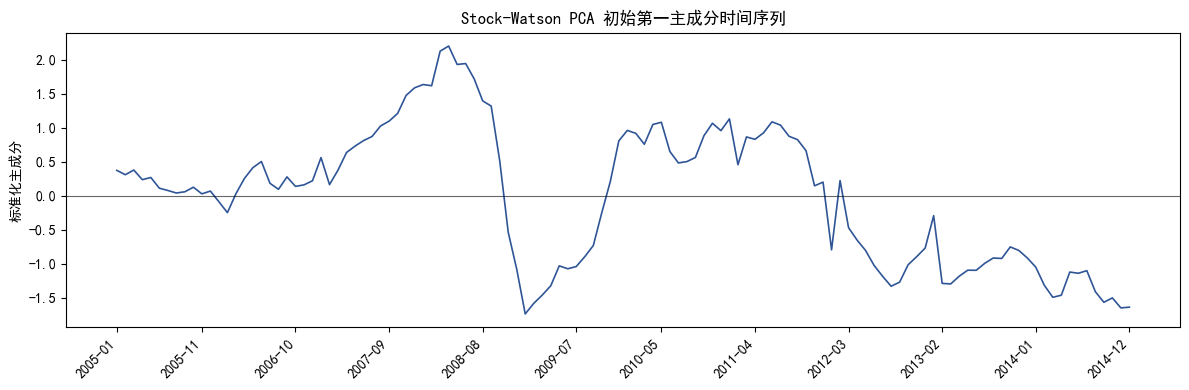

各变量对 PCA 第一主成分的贡献，按载荷平方占比排序：


,载荷lambda,载荷绝对值,载荷平方,观测数,缺失率,进入平衡PCA块,贡献占比,贡献排名
PPI,0.879972,0.879972,0.774350,120,0.000000,True,0.257403,1
社零,0.739792,0.739792,0.547292,118,0.016667,True,0.181926,2
CPI,0.737623,0.737623,0.544088,120,0.000000,True,0.180861,3
工业增加值,0.612003,0.612003,0.374548,120,0.000000,True,0.124504,4
用电量,0.579579,0.579579,0.335912,56,0.533333,False,0.111661,5
固投累计同比_去季节性,0.459507,0.459507,0.211146,110,0.083333,True,0.070187,6
制造业PMI_去季节性,0.448044,0.448044,0.200743,120,0.000000,True,0.066729,7
服务业PMI,0.142267,0.142267,0.020240,35,0.708333,False,0.006728,8


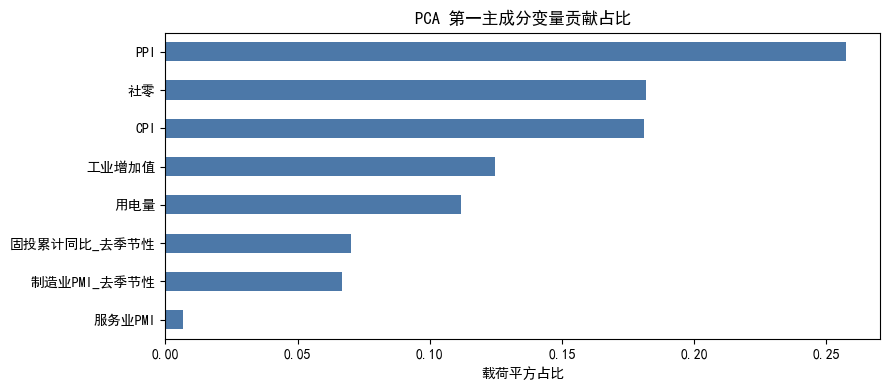

In [28]:

def first_pc_svd(matrix_df: pd.DataFrame):
    """Stock-Watson PCA: one-shot first principal component on a balanced block."""
    if matrix_df.empty or matrix_df.shape[1] == 0:
        raise ValueError("PCA 输入矩阵为空。")

    X = matrix_df.to_numpy(dtype=float)
    if np.isnan(X).any():
        raise ValueError("Stock-Watson PCA 的平衡数据块不能包含 NaN。")

    col_mean = X.mean(axis=0, keepdims=True)
    X_centered = X - col_mean

    u, singular_values, vt = np.linalg.svd(X_centered, full_matrices=False)
    T_bal = X_centered.shape[0]

    factor = np.sqrt(T_bal) * u[:, 0]
    loading = X_centered.T @ factor / T_bal

    fitted = np.outer(factor, loading)
    objective_v = float(np.mean((X_centered - fitted) ** 2))
    explained_ratio = float(singular_values[0] ** 2 / np.sum(singular_values ** 2))

    factor_s = pd.Series(factor, index=matrix_df.index, name="alpha_init_balanced_pca")
    loading_s = pd.Series(loading, index=matrix_df.columns, name="lambda_pca_sw")
    mean_s = pd.Series(col_mean.ravel(), index=matrix_df.columns, name="column_mean_used_in_pca")

    return factor_s, loading_s, mean_s, explained_ratio, objective_v


def choose_balanced_pca_subset(pca_input: pd.DataFrame, min_rows: int = 36, min_cols: int = 2):
    """Choose a balanced block for the one-shot Stock-Watson PCA initialization."""
    coverage = pca_input.notna().mean().sort_values(ascending=False)
    candidate_cols = [col for col in coverage.index if coverage.loc[col] > 0]
    if len(candidate_cols) < min_cols:
        raise ValueError("可用于 PCA 的变量数量不足。")

    best = None
    for k in range(len(candidate_cols), min_cols - 1, -1):
        cols = candidate_cols[:k]
        balanced = pca_input[cols].dropna(how="any")
        if len(balanced) >= min_rows:
            score = len(balanced) * len(cols)
            if best is None or score > best[0]:
                best = (score, balanced, cols)

    if best is None:
        raise ValueError("找不到满足最小样本长度要求的 Stock-Watson PCA 平衡数据块。")

    _, balanced, cols = best
    return balanced.copy(), cols, "stock_watson_balanced_block"


def estimate_loadings_given_factor(observed_df: pd.DataFrame, factor: pd.Series) -> pd.Series:
    """Estimate initial loadings by OLS projection onto the PCA factor."""
    loadings = {}
    for col in observed_df.columns:
        aligned = pd.concat([observed_df[col].rename("y"), factor.rename("f")], axis=1).dropna()
        if len(aligned) < 2:
            loadings[col] = np.nan
            continue
        f = aligned["f"].to_numpy(dtype=float)
        y = aligned["y"].to_numpy(dtype=float)
        denom = float(f @ f)
        loadings[col] = np.nan if denom <= 1e-12 else float(f @ y / denom)
    return pd.Series(loadings, name="lambda_pca_sw")


def estimate_initial_factor_given_loadings(observed_df: pd.DataFrame, loadings: pd.Series) -> pd.Series:
    """One-pass initial factor projection for Kalman/EM starting values only."""
    common_cols = [col for col in observed_df.columns if col in loadings.index and pd.notna(loadings.loc[col])]
    projected = pd.Series(index=observed_df.index, dtype=float, name="alpha_init")

    for idx, row in observed_df[common_cols].iterrows():
        available = row.dropna()
        if available.empty:
            continue
        lam = loadings.loc[available.index].to_numpy(dtype=float)
        y = available.to_numpy(dtype=float)
        denom = float(lam @ lam)
        if denom > 1e-12:
            projected.loc[idx] = float(lam @ y / denom)

    return projected


def stock_watson_pca_initialization(
    observed_df: pd.DataFrame,
    min_balanced_rows: int = 36,
):
    """Stock-Watson PCA initialization consistent with the paper's use of PCA.

    This is a one-shot PCA initializer. It uses a balanced block once, estimates initial
    loadings, and creates starting values for the subsequent Kalman/EM step.
    """
    X_obs = observed_df.astype(float).copy()
    if X_obs.shape[1] == 0:
        raise ValueError("没有可用于 PCA 初始化的变量。")

    balanced, balanced_cols, init_mode = choose_balanced_pca_subset(
        X_obs,
        min_rows=min_balanced_rows,
        min_cols=min(2, max(1, X_obs.shape[1])),
    )

    factor_bal, loading_bal, mean_bal, explained_ratio, objective_v = first_pc_svd(balanced)

    loading_all = estimate_loadings_given_factor(X_obs.loc[factor_bal.index], factor_bal)
    loading_all.loc[loading_bal.index] = loading_bal
    loading_all.name = "lambda_pca_sw"

    alpha_projected = estimate_initial_factor_given_loadings(X_obs, loading_all)
    alpha_projected.loc[factor_bal.index] = factor_bal
    alpha_projected = alpha_projected.interpolate(limit_direction="both").fillna(0.0)
    alpha_projected = (alpha_projected - alpha_projected.mean()) / alpha_projected.std(ddof=0)
    alpha_projected.name = "alpha_init"

    summary = pd.DataFrame([{
        "method": "stock_watson_balanced_pca_one_shot",
        "balanced_rows": len(balanced),
        "balanced_cols": len(balanced_cols),
        "explained_ratio_1": explained_ratio,
        "pca_objective_v": objective_v,
        "convergence_rule": "none; one-shot PCA initialization",
    }])

    return {
        "factor": alpha_projected,
        "loading": loading_all,
        "summary": summary,
        "balanced_cols": balanced_cols,
        "balanced_index": factor_bal.index,
        "initialization_mode": init_mode,
        "explained_ratio_1": explained_ratio,
        "pca_objective_v": objective_v,
    }


pca_input = z_train_df[monthly_model_cols].copy()
pca_sw_results = stock_watson_pca_initialization(
    pca_input,
    min_balanced_rows=max(36, FACTOR_AR_ORDER + 10),
)

alpha_init = pca_sw_results["factor"].copy()
pca_sw_loadings = pca_sw_results["loading"].copy()
pca_sw_summary = pca_sw_results["summary"].copy()
pca_explained_ratio_1 = pca_sw_results["explained_ratio_1"]

orientation_reference_cols = [
    "工业增加值",
    "社零",
    "固投",
]
orientation_reference_col = next((col for col in orientation_reference_cols if col in monthly_model_cols), None)
orientation_corr = np.nan
if orientation_reference_col is not None:
    orientation_df = pd.concat([alpha_init, z_train_df[orientation_reference_col]], axis=1).dropna()
    if len(orientation_df) >= 3:
        orientation_corr = orientation_df.iloc[:, 0].corr(orientation_df.iloc[:, 1])
        if orientation_corr < 0:
            alpha_init = -alpha_init
            pca_sw_loadings = -pca_sw_loadings
            orientation_corr = -orientation_corr

print(f"PCA 初始化方式：{pca_sw_results['initialization_mode']}")
print(f"平衡 PCA 样本期数：{len(pca_sw_results['balanced_index'])}")
print(f"平衡 PCA 变量数：{len(pca_sw_results['balanced_cols'])}")
print("PCA 只用于 Stock-Watson 初始值；后续估计由 Kalman / EM 完成。")
print(f"第一主成分解释率：{pca_explained_ratio_1:.4f}")
print(f"PCA 目标函数 V(F,Lambda)：{pca_sw_results['pca_objective_v']:.6f}")
print(f"方向参考变量：{orientation_reference_col}")
print(f"方向参考相关系数：{orientation_corr:.4f}")

display(pca_sw_summary)

fig, ax = plt.subplots(figsize=(12, 4))
plot_index = alpha_init.index.astype(str)
ax.plot(plot_index, alpha_init, linewidth=1.2, color="#2f5597")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
tick_positions = np.linspace(0, len(plot_index) - 1, min(12, len(plot_index)), dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([plot_index[i] for i in tick_positions], rotation=45, ha="right")
ax.set_title("Stock-Watson PCA 初始第一主成分时间序列")
ax.set_xlabel("")
ax.set_ylabel("标准化主成分")
plt.tight_layout()
plt.show()

pca_contribution_table = pd.DataFrame({
    "载荷lambda": pca_sw_loadings,
    "载荷绝对值": pca_sw_loadings.abs(),
    "载荷平方": pca_sw_loadings.pow(2),
    "观测数": pca_input.notna().sum(),
    "缺失率": pca_input.isna().mean(),
    "进入平衡PCA块": pca_input.columns.isin(pca_sw_results["balanced_cols"]),
})
loading_square_sum = pca_contribution_table["载荷平方"].sum()
pca_contribution_table["贡献占比"] = np.where(
    loading_square_sum > 0,
    pca_contribution_table["载荷平方"] / loading_square_sum,
    np.nan,
)
pca_contribution_table["贡献排名"] = pca_contribution_table["贡献占比"].rank(ascending=False, method="min").astype("Int64")
pca_contribution_table = pca_contribution_table.sort_values("贡献占比", ascending=False)

print("各变量对 PCA 第一主成分的贡献，按载荷平方占比排序：")
display(pca_contribution_table)

fig, ax = plt.subplots(figsize=(9, 4))
plot_contrib = pca_contribution_table["贡献占比"].sort_values(ascending=True)
plot_contrib.plot(kind="barh", ax=ax, color="#4c78a8")
ax.set_title("PCA 第一主成分变量贡献占比")
ax.set_xlabel("载荷平方占比")
ax.set_ylabel("")
plt.tight_layout()
plt.show()



PCA结果分析：
1. 第一主成分时间序列曲线基本符合宏观经济变化阶段。
2. 主成分因子中价格因子权重大，此处保留，将状态因子解释为宏观综合状态因子；后续考虑将状态因子拆成全局、名义和实际

### 9.2 累加器与高阶状态初始值

根据 Harvey 递推累加器：

$$
S_t^{(0)} = s_t S_{t-1}^{(0)} + \alpha_t^{(0)}
$$

同时参考论文中有限阶动态因子设定，将状态向量扩展为：

$$
\xi_t^{(0)} =
\begin{bmatrix}
\alpha_t^{(0)} & \alpha_{t-1}^{(0)} & \cdots & \alpha_{t-p+1}^{(0)} & S_t^{(0)}
\end{bmatrix}'
$$

其中 `FACTOR_AR_ORDER = p`。










In [29]:
S_values = []
S_prev = 0.0
for month, alpha_value in alpha_init.items():
    s_t = accumulator_switch_for_month(month)
    S_t = s_t * S_prev + alpha_value
    S_values.append(S_t)
    S_prev = S_t

S_init = pd.Series(S_values, index=alpha_init.index, name="S_init")

xi_init = pd.DataFrame(index=alpha_init.index)
xi_init["alpha_t"] = alpha_init
for lag in range(1, FACTOR_AR_ORDER):
    xi_init[f"alpha_lag{lag}"] = alpha_init.shift(lag)
xi_init["S_t"] = S_init
xi_init = xi_init.reindex(columns=STATE_NAMES)

xi_init.loc[TRAIN_START:TRAIN_START + 5]


,alpha_t,alpha_lag1,alpha_lag2,alpha_lag3,alpha_lag4,alpha_lag5,alpha_lag6,alpha_lag7,alpha_lag8,alpha_lag9,alpha_lag10,alpha_lag11,alpha_lag12,alpha_lag13,alpha_lag14,S_t
month,,,,,,,,,,,,,,,,
2005-01,0.372500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.372500
2005-02,0.308528,0.372500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.681028
2005-03,0.377066,0.308528,0.372500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.058094
2005-04,0.235350,0.377066,0.308528,0.372500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.235350
2005-05,0.267354,0.235350,0.377066,0.308528,0.372500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.502704
2005-06,0.110190,0.267354,0.235350,0.377066,0.308528,0.3725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.612894


### 9.3 状态转移参数初始值：AR(p)

参考论文的有限阶动态因子设定，令初始因子满足：

$$
\alpha_t^{(0)} = \rho_1^{(0)}\alpha_{t-1}^{(0)} + \rho_2^{(0)}\alpha_{t-2}^{(0)} + \cdots + \rho_p^{(0)}\alpha_{t-p}^{(0)} + u_t
$$

用 OLS 得到初始 AR(p) 系数。共同因子冲击方差继续采用文献归一化：

$$
Var(u_t)=1
$$

因此残差方差只作为诊断值保留，不作为 Kalman filter 的 $Q_t$ 输入。










In [30]:

def ols_slope_no_intercept(x: pd.Series, y: pd.Series, default=np.nan) -> float:
    aligned = pd.concat([x.rename("x"), y.rename("y")], axis=1).dropna()
    if len(aligned) < 2:
        return default
    x_arr = aligned["x"].to_numpy(dtype=float)
    y_arr = aligned["y"].to_numpy(dtype=float)
    denom = float(np.dot(x_arr, x_arr))
    if denom <= 1e-12:
        return default
    return float(np.dot(x_arr, y_arr) / denom)


def companion_matrix_from_ar(ar_params: pd.Series) -> np.ndarray:
    ar_params = ensure_ar_params(ar_params)
    p = len(ar_params)
    companion = np.zeros((p, p), dtype=float)
    companion[0, :] = ar_params.to_numpy(dtype=float)
    if p > 1:
        companion[1:, :-1] = np.eye(p - 1)
    return companion


def ar_spectral_radius(ar_params: pd.Series) -> float:
    """仅作为诊断指标，不再用于 clip 或缩放 AR 参数。"""
    companion = companion_matrix_from_ar(ar_params)
    eigvals = np.linalg.eigvals(companion)
    return float(np.max(np.abs(eigvals))) if len(eigvals) else 0.0


def estimate_ar_no_intercept(series: pd.Series, order: int) -> tuple[pd.Series, pd.Series]:
    """对 alpha_t 做无截距 AR(p) OLS 初始化。"""
    df = pd.DataFrame({"y": series})
    for lag in range(1, order + 1):
        df[f"lag{lag}"] = series.shift(lag)
    df = df.dropna()
    if len(df) <= order:
        raise ValueError(f"有效样本不足，无法估计 AR({order})。")

    y_arr = df["y"].to_numpy(dtype=float)
    X_arr = df[[f"lag{lag}" for lag in range(1, order + 1)]].to_numpy(dtype=float)
    beta = np.linalg.pinv(X_arr.T @ X_arr) @ (X_arr.T @ y_arr)
    ar_params = pd.Series(beta, index=AR_PARAM_NAMES, name="ar_params_init")
    resid = pd.Series(y_arr - X_arr @ beta, index=df.index, name="state_resid_init")
    return ar_params, resid


ar_params_init, state_resid_init = estimate_ar_no_intercept(alpha_init, FACTOR_AR_ORDER)
state_resid_variance_diagnostic = max(float(state_resid_init.dropna().var(ddof=0)), 1e-6)

# 文献归一化：共同因子冲击方差固定为 1，用于识别因子尺度。
STATE_SHOCK_VARIANCE = 1.0

state_param_init = ar_params_init.rename("ar_params_init_no_clip").to_frame()

print(f"Initial AR({FACTOR_AR_ORDER}) spectral radius diagnostic: {ar_spectral_radius(ar_params_init):.4f}; state shock variance: {STATE_SHOCK_VARIANCE:.1f}")


Initial AR(15) spectral radius diagnostic: 0.9566; state shock variance: 1.0


### 9.4 月度变量载荷与误差方差初始值

对每个月度宏观变量单独回归：

$$
x_{i,t} = \lambda_i^{(0)} \alpha_t^{(0)} + \varepsilon_{i,t}
$$

用 OLS 得到：

$$
\lambda_i^{(0)} =
\frac{\sum_t \alpha_t^{(0)} x_{i,t}}{\sum_t (\alpha_t^{(0)})^2}
$$

月度变量误差方差初始值：

$$
h_i^{(0)} = Var\left(x_{i,t} - \lambda_i^{(0)}\alpha_t^{(0)}\right)
$$









In [31]:
lambda_init = {}
h_monthly_init = {}

for col in monthly_model_cols:
    aligned = pd.concat([alpha_init.rename("alpha"), z_train_df[col].rename("x")], axis=1).dropna()
    lam = ols_slope_no_intercept(aligned["alpha"], aligned["x"], default=0.0)
    resid = aligned["x"] - lam * aligned["alpha"] if len(aligned) else pd.Series(dtype=float)
    lambda_init[col] = lam
    h_monthly_init[col] = max(float(resid.var(ddof=0)), 1e-6) if len(resid) else np.nan

lambda_init = pd.Series(lambda_init, name="lambda_init")
h_monthly_init = pd.Series(h_monthly_init, name="h_init")

monthly_param_init = pd.concat([lambda_init, h_monthly_init], axis=1)
monthly_param_init








,lambda_init,h_init
服务业PMI,0.174504,0.926487
工业增加值,0.684687,0.531204
用电量,0.577472,0.605285
社零,0.701449,0.504540
CPI,0.712544,0.492281
PPI,0.866484,0.249205
制造业PMI_去季节性,0.480496,0.769124
固投累计同比_去季节性,0.459901,0.788854


### 9.5 GDP 载荷与观测误差方差初始值

GDP 在季度末加载到 Harvey 累加器：

$$
GDP_t = \lambda_{GDP}^{(0)} S_t^{(0)} + \varepsilon_{GDP,t}^{(0)}
$$

其中 $\lambda_{GDP}^{(0)}$ 用无截距 OLS 初始化，误差方差只在季度末且 GDP 有观测的月份计算。










In [32]:
gdp_init_df = pd.concat([
    z_train_df[GDP_COL].rename("gdp"),
    S_init.rename("S_init"),
], axis=1).dropna()
gdp_init_df = gdp_init_df.loc[[is_quarter_end_month(month) for month in gdp_init_df.index]]

gdp_lambda_init = ols_slope_no_intercept(gdp_init_df["S_init"], gdp_init_df["gdp"], default=1.0)
gdp_resid_init = gdp_init_df["gdp"] - gdp_lambda_init * gdp_init_df["S_init"]
h_gdp_init = max(float(gdp_resid_init.var(ddof=0)), 1e-6)

gdp_param_init = pd.Series({
    "lambda_gdp_init": gdp_lambda_init,
    "h_gdp_init": h_gdp_init,
    "gdp_obs_used": len(gdp_init_df),
})
gdp_param_init








lambda_gdp_init     0.232337
h_gdp_init          0.533933
gdp_obs_used       40.000000
dtype: float64

### 9.6 汇总初始对象

后续 Kalman filter 需要的初始对象包括：

$$
\xi_t^{(0)},\quad \rho_1^{(0)},\ldots,\rho_p^{(0)},\quad Var(u_t)=1,\quad \lambda_i^{(0)},\quad h_i^{(0)},\quad h_{GDP}^{(0)}
$$

这里先构造完整观测误差协方差初始矩阵：

$$
H^{(0)} = diag\left(h_{GDP}^{(0)}, h_1^{(0)}, h_2^{(0)}, \ldots, h_N^{(0)}\right)
$$

注意：$H^{(0)}$ 仍然是初始值。后续 EM 更新时，$H$ 要使用 smoother 给出的状态均值和状态协方差来更新。










In [33]:
h_init = pd.concat([
    pd.Series({GDP_COL: h_gdp_init}, name="h_init"),
    h_monthly_init,
])
h_init = h_init.loc[model_cols_valid]

H_init = pd.DataFrame(
    np.diag(h_init.to_numpy(dtype=float)),
    index=model_cols_valid,
    columns=model_cols_valid,
)

lambda_full_init = pd.concat([
    pd.Series({GDP_COL: gdp_lambda_init}, name="lambda_init"),
    lambda_init.rename("lambda_init"),
]).loc[model_cols_valid]

initialization_artifacts = {
    "alpha_init": alpha_init,
    "S_init": S_init,
    "xi_init": xi_init,
    "ar_params_init": ar_params_init,
    "pca_sw_loadings": pca_sw_loadings,
    "pca_sw_summary": pca_sw_summary,
    "state_shock_variance": STATE_SHOCK_VARIANCE,
    "state_resid_variance_diagnostic": state_resid_variance_diagnostic,
    "lambda_init": lambda_full_init,
    "h_init": h_init,
    "H_init": H_init,
}

print("初始化对象已生成：")
print(", ".join(initialization_artifacts.keys()))

init_summary = pd.concat([
    ar_params_init.rename("value"),
    pd.Series({
        "ar_spectral_radius_init_diagnostic_no_clip": ar_spectral_radius(ar_params_init),
        "state_shock_variance_normalized": STATE_SHOCK_VARIANCE,
        "state_resid_variance_diagnostic": state_resid_variance_diagnostic,
        "lambda_gdp_init": gdp_lambda_init,
        "h_gdp_init": h_gdp_init,
        "pca_explained_ratio_1": pca_explained_ratio_1,
    }, name="value"),
])
init_summary.to_frame("value")








初始化对象已生成：
alpha_init, S_init, xi_init, ar_params_init, pca_sw_loadings, pca_sw_summary, state_shock_variance, state_resid_variance_diagnostic, lambda_init, h_init, H_init


,value
rho_1,1.067156
rho_2,0.143917
rho_3,-0.212604
rho_4,-0.129681
rho_5,0.109198
rho_6,0.046215
rho_7,-0.009804
rho_8,-0.054295
rho_9,-0.073578
rho_10,-0.007702


### 9.7 各观测变量自身的 AR(15) 诊断

主模型的状态转移只使用共同因子 $\alpha_t^{(0)}$ 的 AR(15) 初始化。这里额外对每个观测变量自身估计一次无截距 AR(15)，仅用于诊断变量自身的持续性：

$$
x_{i,t} = \phi_{i,1}x_{i,t-1}+\phi_{i,2}x_{i,t-2}+\cdots+\phi_{i,15}x_{i,t-15}+u_{i,t}
$$

缺失值较多的变量可能没有足够连续样本，表中会标记为估计失败。

Observed-variable AR(15) diagnostic: successful=6/9, max_radius=1.0185


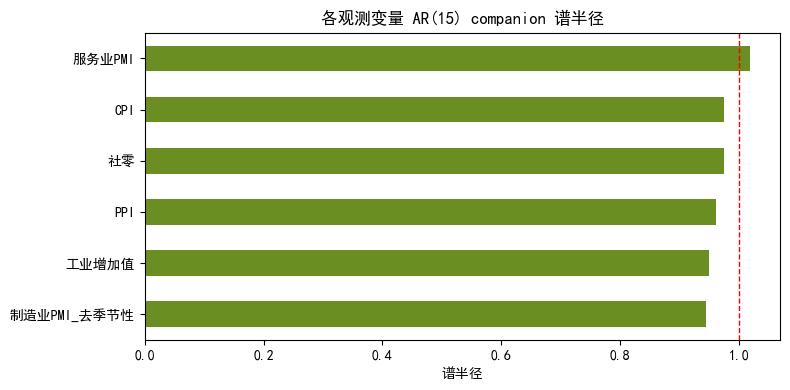

In [34]:
def ar_design_effective_rows(series: pd.Series, order: int) -> int:
    df = pd.DataFrame({"y": series})
    for lag in range(1, order + 1):
        df[f"lag{lag}"] = series.shift(lag)
    return int(df.dropna().shape[0])


observed_ar15_rows = []
observed_ar15_coef = []

for col in model_cols_valid:
    series = z_train_df[col].astype(float)
    n_obs = int(series.notna().sum())
    n_ar_rows = ar_design_effective_rows(series, FACTOR_AR_ORDER)
    row = {
        "变量": col,
        "观测数": n_obs,
        "AR有效样本": n_ar_rows,
        "估计成功": False,
        "谱半径": np.nan,
        "残差方差": np.nan,
        "说明": "",
    }
    try:
        coef, resid = estimate_ar_no_intercept(series, FACTOR_AR_ORDER)
        row.update({
            "估计成功": True,
            "谱半径": ar_spectral_radius(coef),
            "残差方差": float(resid.var(ddof=0)),
            "说明": "",
        })
        observed_ar15_coef.append(coef.rename(col))
    except Exception as exc:
        row["说明"] = str(exc)
        observed_ar15_coef.append(pd.Series(np.nan, index=AR_PARAM_NAMES, name=col))
    observed_ar15_rows.append(row)

observed_ar15_summary = pd.DataFrame(observed_ar15_rows).set_index("变量")
observed_ar15_coefficients = pd.DataFrame(observed_ar15_coef)
observed_ar15_coefficients.index.name = "变量"

ar15_success_col = observed_ar15_summary.columns[2]
ar15_radius_col = observed_ar15_summary.columns[3]
ar15_success_mask = observed_ar15_summary[ar15_success_col].astype(bool)
ar15_success_count = int(ar15_success_mask.sum())
ar15_max_radius = float(observed_ar15_summary.loc[ar15_success_mask, ar15_radius_col].max()) if ar15_success_count else np.nan
print(f"Observed-variable AR(15) diagnostic: successful={ar15_success_count}/{len(observed_ar15_summary)}, max_radius={ar15_max_radius:.4f}")

successful_ar15 = observed_ar15_summary.loc[observed_ar15_summary["估计成功"]]
if not successful_ar15.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    successful_ar15["谱半径"].sort_values().plot(kind="barh", ax=ax, color="#6b8e23")
    ax.axvline(1.0, color="red", linewidth=1, linestyle="--")
    ax.set_title("各观测变量 AR(15) companion 谱半径")
    ax.set_xlabel("谱半径")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


## 10. 构造 Kalman filter 系统矩阵

本节按文献附录 A.1-A.2 的口径，先把每一期 Kalman filter 需要的状态方程和观测方程矩阵组装出来。

文献状态方程写作：

$$
\alpha_{t+1}=T_t\alpha_t+R_t\eta_t,
\qquad
\eta_t\sim N(0,Q)
$$

本文 notebook 的状态向量是月频版本：

$$
\xi_t=
\begin{bmatrix}
\alpha_t & \alpha_{t-1} & \cdots & \alpha_{t-p+1} & S_t
\end{bmatrix}'
$$

其中 $S_t$ 是季度 GDP 对应的 Harvey sum accumulator：

$$
S_t=s_t S_{t-1}+\alpha_t
$$

观测方程为：

$$
y_t=Z_t\xi_t+\varepsilon_t,
\qquad
\varepsilon_t\sim N(0,H)
$$

由于每期有些变量缺失，文献用选择矩阵 $W_t$ 处理部分观测：

$$
y_t^*=W_t y_t
$$

$$
Z_t^*=W_t Z_t
$$

$$
H_t^*=W_t H W_t'
$$

所以本节输出的核心对象是：

$$
T_t,\quad Q_t,\quad y_t^*,\quad Z_t^*,\quad H_t^*,\quad W_t
$$

**与原文的必要差异**

1. 原文是周频金融条件指数，状态中有 monthly average、monthly sum、quarterly sum 三个 accumulator；本 notebook 是月频宏观变量和季度 GDP，因此只保留季度 sum accumulator $S_t$。
2. 原文记号用 $\alpha_t$ 表示整个状态；本 notebook 为了区分共同因子和状态向量，用 $\xi_t$ 表示状态向量，用 $\alpha_t$ 表示状态向量里的当期共同因子。
3. 原文将状态扰动方差归一化；本 notebook 同样设 $Var(\eta_t)=1$。

In [35]:
def build_state_transition_system(month: pd.Period, ar_params: pd.Series):
    """构造当月状态转移矩阵 F_t 和状态扰动协方差 Q_t。"""
    F_t = harvey_transition_matrix(ar_params=ar_params, month=month)
    shock_loading = harvey_shock_loading(R=1.0)
    Q_t = STATE_SHOCK_VARIANCE * pd.DataFrame(
        np.outer(shock_loading, shock_loading),
        index=STATE_NAMES,
        columns=STATE_NAMES,
    )
    return F_t, Q_t


def build_kalman_system_for_month(month: pd.Period, y_panel: pd.DataFrame):
    """构造当月 Kalman filter 需要的 F_t、Q_t、y_t*、Z_t*、H_t*、W_t。"""
    F_t, Q_t = build_state_transition_system(month, ar_params=ar_params_init)
    y_star_t, Z_star_t, H_star_t, W_t = build_selected_observation_system_for_month(
        month=month,
        y_panel=y_panel,
        monthly_loadings=lambda_init,
        H_full_t=H_init,
    )
    return {
        "F_t": F_t,
        "Q_t": Q_t,
        "y_star_t": y_star_t,
        "Z_star_t": Z_star_t,
        "H_star_t": H_star_t,
        "W_t": W_t,
    }


state_m0 = pd.Series(0.0, index=STATE_NAMES, name="m0")
state_P0 = pd.DataFrame(
    np.eye(len(STATE_NAMES)) * 10.0,
    index=STATE_NAMES,
    columns=STATE_NAMES,
)

# 示例展示训练窗口内第一个 GDP 有观测的月份，展示 Kalman filter 当月所需的关键矩阵。
example_month = z_model_df[GDP_COL].first_valid_index()
kalman_example = build_kalman_system_for_month(example_month, z_model_df)

print(f"示例月份：{example_month}")
print(f"当月可观测变量数：{len(kalman_example['y_star_t'])}")



示例月份：2005-03
当月可观测变量数：7


## 11. Kalman Filter Forward Recursion

This section follows the Durbin and Koopman notation used in Appendix A.1 of the paper. Given $a_t$ and $P_t$:

$$
v_t = y_t - Z_t a_t
$$

$$
F_t = Z_tP_tZ_t' + H
$$

$$
K_t = T_tP_tZ_t'F_t^{-1}
$$

$$
L_t = T_t - K_tZ_t
$$

$$
a_{t+1} = T_ta_t + K_tv_t
$$

$$
P_{t+1} = T_tP_tL_t' + RQR'
$$

With missing observations, the code uses the selected system:

$$
y_t^*,\quad Z_t^*,\quad H_t^*
$$

so that:

$$
v_t = y_t^* - Z_t^* a_t
$$

$$
F_t^* = Z_t^*P_tZ_t^{*'} + H_t^*
$$

In code, `Omega_t` is the paper's $F_t^*$, named differently to avoid collision with the transition matrix. The log likelihood follows paper Eq. (4), omitting the normal constant.


In [36]:
def _kalman_filter_core(
    months,
    system_builder,
    transition_builder,
    a1: pd.Series | None = None,
    P1: pd.DataFrame | None = None,
) -> dict:
    """Run the Kalman filter using the paper's Appendix A.1 recursion."""
    state_dim = len(STATE_NAMES)
    predicted_state_rows = []
    filtered_state_rows = []
    loglike_rows = []
    predicted_cov = {}
    filtered_cov = {}
    innovation = {}
    innovation_cov = {}
    kalman_gain = {}
    L_matrices = {}

    a_t = (state_m0 if a1 is None else a1).reindex(STATE_NAMES).fillna(0.0).to_numpy(dtype=float)
    P_t = (state_P0 if P1 is None else P1).reindex(index=STATE_NAMES, columns=STATE_NAMES).fillna(0.0).to_numpy(dtype=float)

    for idx, month in enumerate(months):
        next_month = months[idx + 1] if idx + 1 < len(months) else None
        system_t = system_builder(month)
        Z_star_t = system_t["Z_star_t"].to_numpy(dtype=float)
        H_star_t = system_t["H_star_t"].to_numpy(dtype=float)
        y_star_t = system_t["y_star_t"].to_numpy(dtype=float)

        if next_month is None:
            T_t = np.zeros((state_dim, state_dim), dtype=float)
            Q_next = np.zeros((state_dim, state_dim), dtype=float)
        else:
            T_t, Q_next = transition_builder(next_month)

        P_t = (P_t + P_t.T) / 2
        n_obs_t = len(y_star_t)
        if n_obs_t > 0:
            v_t = y_star_t - Z_star_t @ a_t
            Omega_t = Z_star_t @ P_t @ Z_star_t.T + H_star_t
            Omega_t = (Omega_t + Omega_t.T) / 2
            Omega_inv_t = np.linalg.pinv(Omega_t)
            K_t = T_t @ P_t @ Z_star_t.T @ Omega_inv_t
            L_t = T_t - K_t @ Z_star_t

            m_filt_t = a_t + P_t @ Z_star_t.T @ Omega_inv_t @ v_t
            P_filt_t = P_t - P_t @ Z_star_t.T @ Omega_inv_t @ Z_star_t @ P_t
            P_filt_t = (P_filt_t + P_filt_t.T) / 2

            sign, logdet = np.linalg.slogdet(Omega_t)
            if sign > 0:
                # Paper Eq. (4): omit n_obs_t * log(2*pi).
                loglike_t = float(-0.5 * (logdet + v_t.T @ Omega_inv_t @ v_t))
            else:
                loglike_t = np.nan
        else:
            v_t = np.array([])
            Omega_t = np.empty((0, 0))
            K_t = np.empty((state_dim, 0))
            L_t = T_t
            m_filt_t = a_t
            P_filt_t = P_t
            loglike_t = 0.0

        predicted_state_rows.append(pd.Series(a_t, index=STATE_NAMES, name=month))
        filtered_state_rows.append(pd.Series(m_filt_t, index=STATE_NAMES, name=month))
        predicted_cov[month] = pd.DataFrame(P_t, index=STATE_NAMES, columns=STATE_NAMES)
        filtered_cov[month] = pd.DataFrame(P_filt_t, index=STATE_NAMES, columns=STATE_NAMES)
        innovation[month] = pd.Series(v_t, index=system_t["y_star_t"].index, name=month)
        innovation_cov[month] = pd.DataFrame(Omega_t, index=system_t["y_star_t"].index, columns=system_t["y_star_t"].index)
        kalman_gain[month] = pd.DataFrame(K_t, index=STATE_NAMES, columns=system_t["y_star_t"].index)
        L_matrices[month] = pd.DataFrame(L_t, index=STATE_NAMES, columns=STATE_NAMES)
        loglike_rows.append({"month": month, "n_obs": n_obs_t, "loglike": loglike_t})

        if next_month is not None:
            a_t = T_t @ a_t + K_t @ v_t
            P_t = T_t @ P_t @ L_t.T + Q_next
            P_t = (P_t + P_t.T) / 2

    predicted_state = pd.DataFrame(predicted_state_rows)
    filtered_state = pd.DataFrame(filtered_state_rows)
    loglike_by_month = pd.DataFrame(loglike_rows).set_index("month")

    return {
        "predicted_state": predicted_state,
        "filtered_state": filtered_state,
        "predicted_cov": predicted_cov,
        "filtered_cov": filtered_cov,
        "innovation": innovation,
        "innovation_cov": innovation_cov,
        "kalman_gain": kalman_gain,
        "L": L_matrices,
        "loglike_by_month": loglike_by_month,
        "loglike": loglike_by_month["loglike"].sum(skipna=True),
    }


def run_kalman_filter(y_panel: pd.DataFrame, start: pd.Period, end: pd.Period):
    """Run the initial-parameter Kalman filter with the paper recursion."""
    months = list(y_panel.loc[start:end].index)

    return _kalman_filter_core(
        months=months,
        system_builder=lambda month: build_kalman_system_for_month(month, y_panel),
        transition_builder=lambda month: tuple(
            item.to_numpy(dtype=float) for item in build_state_transition_system(month, ar_params=ar_params_init)
        ),
    )


filter_results = run_kalman_filter(z_model_df, TRAIN_START, TRAIN_END)
predicted_state = filter_results["predicted_state"]
filtered_state = filter_results["filtered_state"]

print(f"Initial Kalman filter log likelihood: {filter_results['loglike']:.4f}")


Initial Kalman filter log likelihood: -408.9125


## 12. Kalman Smoother Backward Recursion

Appendix A.1 uses the $r_t$ and $N_t$ backward smoother with terminal conditions:

$$
r_T=0,
\qquad
N_T=0
$$

Backward recursion:

$$
r_{t-1}=Z_t'F_t^{-1}v_t+L_t'r_t
$$

$$
N_{t-1}=Z_t'F_t^{-1}Z_t+L_t'N_tL_t
$$

Smoothed state and covariance:

$$
\hat{\alpha}_t=a_t+P_tr_{t-1}
$$

$$
V_t=P_t-P_tN_{t-1}P_t
$$

The paper also computes the lag-one covariance needed by the EM M-step:

$$
J_t=P_tL_{t-1}'(I-N_{t-1}P_t)
$$

The code returns `smoothed_state`, `smoothed_cov`, and `lag_one_smoothed_cov` for the M-step.


Initial smoother generated with paper r/N recursion for 120 periods.


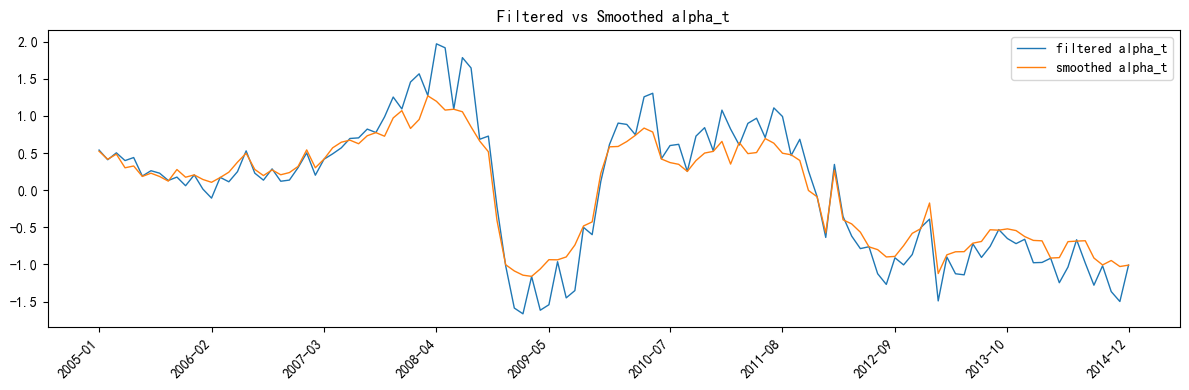

In [37]:
def _durbin_koopman_smoother_core(
    filter_results: dict,
    months: list[pd.Period],
    system_builder,
    transition_builder,
) -> dict:
    """Run the backward smoother using the paper's r/N recursion."""
    state_dim = len(STATE_NAMES)
    eye_state = np.eye(state_dim)

    r_next = np.zeros(state_dim, dtype=float)
    N_next = np.zeros((state_dim, state_dim), dtype=float)

    smoothed_state_rows = {}
    smoothed_cov = {}
    r_prior = {}
    N_prior = {}
    L_by_month = {}

    for idx in range(len(months) - 1, -1, -1):
        month = months[idx]
        next_month = months[idx + 1] if idx + 1 < len(months) else None

        system_t = system_builder(month)
        Z_t = system_t["Z_star_t"].to_numpy(dtype=float)
        v_t = filter_results["innovation"][month].to_numpy(dtype=float)
        Omega_t = filter_results["innovation_cov"][month].to_numpy(dtype=float)
        P_t = filter_results["predicted_cov"][month].to_numpy(dtype=float)
        a_t = filter_results["predicted_state"].loc[month].to_numpy(dtype=float)

        if next_month is None:
            T_to_next = np.zeros((state_dim, state_dim), dtype=float)
        else:
            T_to_next = transition_builder(next_month)

        if len(v_t) > 0:
            Omega_inv_t = np.linalg.pinv(Omega_t)
            Z_omega_inv = Z_t.T @ Omega_inv_t
            score_t = Z_omega_inv @ v_t
            info_t = Z_omega_inv @ Z_t
            K_dk_t = T_to_next @ P_t @ Z_t.T @ Omega_inv_t
            L_t = T_to_next - K_dk_t @ Z_t
        else:
            score_t = np.zeros(state_dim, dtype=float)
            info_t = np.zeros((state_dim, state_dim), dtype=float)
            L_t = T_to_next

        r_prev = score_t + L_t.T @ r_next
        N_prev = info_t + L_t.T @ N_next @ L_t
        N_prev = (N_prev + N_prev.T) / 2

        alpha_smooth_t = a_t + P_t @ r_prev
        V_t = P_t - P_t @ N_prev @ P_t
        V_t = (V_t + V_t.T) / 2

        smoothed_state_rows[month] = pd.Series(alpha_smooth_t, index=STATE_NAMES, name=month)
        smoothed_cov[month] = pd.DataFrame(V_t, index=STATE_NAMES, columns=STATE_NAMES)
        r_prior[month] = pd.Series(r_prev, index=STATE_NAMES, name=month)
        N_prior[month] = pd.DataFrame(N_prev, index=STATE_NAMES, columns=STATE_NAMES)
        L_by_month[month] = pd.DataFrame(L_t, index=STATE_NAMES, columns=STATE_NAMES)

        r_next = r_prev
        N_next = N_prev

    smoothed_state = pd.DataFrame([smoothed_state_rows[month] for month in months])

    lag_one_smoothed_cov = {}
    for idx in range(1, len(months)):
        month = months[idx]
        prev_month = months[idx - 1]
        P_t = filter_results["predicted_cov"][month].to_numpy(dtype=float)
        L_prev = L_by_month[prev_month].to_numpy(dtype=float)
        N_t_minus_1 = N_prior[month].to_numpy(dtype=float)
        cov_t_tminus1 = P_t @ L_prev.T @ (eye_state - N_t_minus_1 @ P_t)
        lag_one_smoothed_cov[month] = pd.DataFrame(
            cov_t_tminus1,
            index=STATE_NAMES,
            columns=STATE_NAMES,
        )

    return {
        "smoothed_state": smoothed_state,
        "smoothed_cov": smoothed_cov,
        "lag_one_smoothed_cov": lag_one_smoothed_cov,
        "r_prior": r_prior,
        "N_prior": N_prior,
        "L": L_by_month,
    }


def run_kalman_smoother(filter_results: dict, start: pd.Period, end: pd.Period):
    """Run the initial-parameter Kalman smoother with the paper recursion."""
    months = list(filter_results["filtered_state"].loc[start:end].index)

    return _durbin_koopman_smoother_core(
        filter_results=filter_results,
        months=months,
        system_builder=lambda month: build_kalman_system_for_month(month, z_model_df),
        transition_builder=lambda month: build_state_transition_system(month, ar_params=ar_params_init)[0].to_numpy(dtype=float),
    )


smoother_results = run_kalman_smoother(filter_results, TRAIN_START, TRAIN_END)
smoothed_state = smoother_results["smoothed_state"]

print(f"Initial smoother generated with paper r/N recursion for {len(smoothed_state)} periods.")

fig, ax = plt.subplots(figsize=(12, 4))
plot_index = smoothed_state.index.astype(str)
ax.plot(plot_index, filtered_state["alpha_t"], label="filtered alpha_t", linewidth=1)
ax.plot(plot_index, smoothed_state["alpha_t"], label="smoothed alpha_t", linewidth=1)
tick_positions = np.linspace(0, len(plot_index) - 1, 10, dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([plot_index[i] for i in tick_positions], rotation=45, ha="right")
ax.set_title("Filtered vs Smoothed alpha_t")
ax.legend()
plt.tight_layout()
plt.show()


## 13. EM M-step Following Appendix A.3

Appendix A.3 maximizes the conditional expectation of the complete-data log likelihood. The smoother supplies:

> $$
> E(\alpha_t\mid Y)=\hat{\alpha}_t
> $$

> $$
> Var(\alpha_t\mid Y)=V_t
> $$

> $$
> Cov(\alpha_t,\alpha_{t-1}\mid Y)=J_t'
> $$

The paper's update equations are:

> $$
> T^{new}=BA^{-1}
> $$

> $$
> Z^{new}=ED^{-1}
> $$

Under the restricted measurement structure, each indicator loads on one state element, so loadings and diagonal $H_i$ are updated variable by variable. The EM loop also updates $a_1$ to the first smoothed state and keeps $P_1$ at the baseline initial covariance, as described in Appendix A.3.


### 13.1 Update Transition Dynamics AR(p)

The unrestricted paper update is:

> $$
> T^{new}=BA^{-1}
> $$

For the first row of the AR(15) companion block, define:

> $$
> \alpha_t=\rho_1\alpha_{t-1}+\rho_2\alpha_{t-2}+\cdots+\rho_p\alpha_{t-p}+u_t
> $$

> $$
> x_{t-1}=\begin{bmatrix}\alpha_{t-1} & \alpha_{t-2} & \cdots & \alpha_{t-p}\end{bmatrix}'
> $$

Then the corresponding $BA^{-1}$ update is:

> $$
> \rho^{new}=\left[\sum_t E(x_{t-1}x_{t-1}'\mid Y)\right]^{-1}\left[\sum_t E(x_{t-1}\alpha_t\mid Y)\right]
> $$

The companion spectral radius is reported as a diagnostic only; it is not clipped or rescaled.


In [38]:

def update_ar_params_from_smoother(
    smoothed_state: pd.DataFrame,
    smoothed_cov: dict,
    lag_one_smoothed_cov: dict,
    return_details: bool = False,
):
    """按 EM 条件矩更新 alpha_t 的 AR(p) 系数；不做谱半径 clip 或缩放。"""
    numerator = np.zeros(FACTOR_AR_ORDER, dtype=float)
    denominator = np.zeros((FACTOR_AR_ORDER, FACTOR_AR_ORDER), dtype=float)

    months = list(smoothed_state.index)
    for month in months[1:]:
        prev_month = month - 1
        if prev_month not in smoothed_state.index or month not in lag_one_smoothed_cov:
            continue

        y_mean = float(smoothed_state.loc[month, "alpha_t"])
        x_mean = smoothed_state.loc[prev_month, ALPHA_STATE_NAMES].to_numpy(dtype=float)

        cov_y_x = lag_one_smoothed_cov[month].loc["alpha_t", ALPHA_STATE_NAMES].to_numpy(dtype=float)
        cov_x_x = smoothed_cov[prev_month].loc[ALPHA_STATE_NAMES, ALPHA_STATE_NAMES].to_numpy(dtype=float)

        numerator += x_mean * y_mean + cov_y_x
        denominator += np.outer(x_mean, x_mean) + cov_x_x

    if np.linalg.cond(denominator) > 1e12:
        beta = np.linalg.pinv(denominator) @ numerator
    else:
        beta = np.linalg.solve(denominator, numerator)

    ar_params_new = pd.Series(beta, index=AR_PARAM_NAMES, name="ar_params_new")

    details = {
        "ar_params": ar_params_new,
        "ar_spectral_radius": ar_spectral_radius(ar_params_new),
        "ar_numerator": numerator,
        "ar_denominator": denominator,
    }
    return details if return_details else ar_params_new


ar_em_1_details = update_ar_params_from_smoother(
    smoothed_state=smoothed_state,
    smoothed_cov=smoother_results["smoothed_cov"],
    lag_one_smoothed_cov=smoother_results["lag_one_smoothed_cov"],
    return_details=True,
)
ar_em_1 = ar_em_1_details["ar_params"]

pd.concat([
    ar_params_init.rename("old"),
    ar_em_1.rename("ar_after_one_m_step"),
], axis=1).assign(
    spectral_radius_after_one_m_step=ar_em_1_details["ar_spectral_radius"],
)








,old,ar_after_one_m_step,spectral_radius_after_one_m_step
rho_1,1.067156,0.258859,0.918775
rho_2,0.143917,0.778449,0.918775
rho_3,-0.212604,-0.007451,0.918775
rho_4,-0.129681,-0.038065,0.918775
rho_5,0.109198,-0.061284,0.918775
rho_6,0.046215,-0.023900,0.918775
rho_7,-0.009804,0.009774,0.918775
rho_8,-0.054295,-0.007402,0.918775
rho_9,-0.073578,-0.035060,0.918775
rho_10,-0.007702,-0.016721,0.918775


### 13.2 更新观测载荷 Z

文献 unrestricted 更新为：

> $$
> Z^{new}=ED^{-1}
> $$

其中：

> $$
> D=\sum_{t=1}^{T}E(\xi_t\xi_t'\mid Y)
> $$

> $$
> E=\sum_{t=1}^{T}y_t\hat{\xi}_t'
> $$

但文献随后说明，在模型受限结构下，每个指标只加载到一个状态元素。若变量 $i$ 加载到状态元素 $j$，则：

> $$
> y_{i,t}=\lambda_i\xi_{j,t}+\varepsilon_{i,t}
> $$

只使用该变量实际有观测的时期 $\mathcal{T}_i$：

> $$
> \lambda_i^{new}
> =
> \frac{
> \sum_{t\in\mathcal{T}_i} y_{i,t}\hat{\xi}_{j,t}
> }{
> \sum_{t\in\mathcal{T}_i}E(\xi_{j,t}^2\mid Y)
> }
> $$

其中：

> $$
> E(\xi_{j,t}^2\mid Y)=\hat{\xi}_{j,t}^2+V_{j,j,t}
> $$

本 notebook 使用同一受限载荷更新：月度变量加载到 $\alpha_t$，GDP 加载到 $S_t$。

In [39]:
def state_name_for_observed_variable(col: str) -> str:
    """月度变量加载到 alpha_t，GDP 加载到 S_t。"""
    return "S_t" if col == GDP_COL else "alpha_t"


def update_loadings_from_smoother(y_panel: pd.DataFrame, smoothed_state: pd.DataFrame, smoothed_cov: dict) -> pd.DataFrame:
    """按文献受限 Z 结构，逐变量更新载荷。"""
    rows = []

    for col in model_cols_valid:
        state_name = state_name_for_observed_variable(col)
        observed = y_panel.loc[smoothed_state.index, col].dropna()

        numerator = 0.0
        denominator = 0.0
        for month, y_value in observed.items():
            state_mean = float(smoothed_state.loc[month, state_name])
            state_var = float(smoothed_cov[month].loc[state_name, state_name])
            numerator += float(y_value) * state_mean
            denominator += state_mean**2 + state_var

        if denominator <= 1e-12 or len(observed) == 0:
            lambda_new = np.nan
        else:
            lambda_new = numerator / denominator

        lambda_old = float(lambda_full_init.loc[col])
        rows.append({
            "variable": col,
            "loaded_state": state_name,
            "n_obs": len(observed),
            "lambda_old": lambda_old,
            "lambda_new": lambda_new,
        })

    return pd.DataFrame(rows).set_index("variable")


loading_update = update_loadings_from_smoother(
    y_panel=z_model_df,
    smoothed_state=smoothed_state,
    smoothed_cov=smoother_results["smoothed_cov"],
)

print(f"One-step loading update prepared for {loading_update['lambda_new'].notna().sum()} observed variables.")








One-step loading update prepared for 9 observed variables.


### 13.3 Update Observation Error Variance H

The paper uses diagonal $H$ and updates each observed variable separately. If variable $i$ loads on state element $j$:

> $$
> H_i^{new}=\frac{1}{T_i}\sum_{t\in\mathcal{T}_i}\left(y_{i,t}-\lambda_i^{new}\hat{\xi}_{j,t}\right)^2
> $$

where $\mathcal{T}_i$ contains only periods in which variable $i$ is observed. The code follows this variable-by-variable mean squared smoothed residual update.


In [40]:
def update_H_from_smoother(
    y_panel: pd.DataFrame,
    smoothed_state: pd.DataFrame,
    smoothed_cov: dict,
    loading_update: pd.DataFrame,
    min_variance: float = 1e-6,
) -> tuple[pd.Series, pd.DataFrame]:
    """Update diagonal H using the paper's EM Updating Equation 3."""
    h_new = {}

    for col in model_cols_valid:
        state_name = loading_update.loc[col, "loaded_state"]
        lam = float(loading_update.loc[col, "lambda_new"])
        observed = y_panel.loc[smoothed_state.index, col].dropna()

        if len(observed) == 0 or not np.isfinite(lam):
            h_new[col] = np.nan
            continue

        sq_resid_sum = 0.0
        for month, y_value in observed.items():
            state_mean = float(smoothed_state.loc[month, state_name])
            resid = float(y_value) - lam * state_mean
            sq_resid_sum += resid**2

        h_new[col] = max(sq_resid_sum / len(observed), min_variance)

    h_new = pd.Series(h_new, name="h_new").loc[model_cols_valid]
    H_new = pd.DataFrame(
        np.diag(h_new.to_numpy(dtype=float)),
        index=model_cols_valid,
        columns=model_cols_valid,
    )
    return h_new, H_new


h_em_1, H_em_1 = update_H_from_smoother(
    y_panel=z_model_df,
    smoothed_state=smoothed_state,
    smoothed_cov=smoother_results["smoothed_cov"],
    loading_update=loading_update,
)

h_update = pd.concat([
    h_init.rename("h_old"),
    h_em_1.rename("h_new"),
], axis=1)

em_m_step_update_1 = loading_update.join(h_update)
em_m_step_update_1["h_positive"] = em_m_step_update_1["h_new"] > 0

print(f"One-step M-step check: H_new all positive = {bool(em_m_step_update_1['h_positive'].all())}; state shock variance = {STATE_SHOCK_VARIANCE:.1f}")


One-step M-step check: H_new all positive = True; state shock variance = 1.0


### 13.4 One M-step Summary

One M-step is not the final converged estimate. Full training iterates:

> $$
> \text{Kalman filter}\rightarrow\text{Kalman smoother}\rightarrow\text{M-step}
> $$

until the paper Eq. (4) log likelihood is stable. The convergence threshold is:

> $$
> \left|\frac{\log L^{(k)}-\log L^{(k-1)}}{\left(\log L^{(k)}+\log L^{(k-1)}\right)/2}\right|<10^{-6}
> $$

Replication status:

1. Kalman filter uses the paper's $a_t,P_t,K_t,L_t$ recursion.
2. Kalman smoother uses the paper's $r_t,N_t$ recursion and returns lag-one covariance for the M-step.
3. M-step updates AR(15), $Z$, and diagonal $H$ following Appendix A.3, with $Var(u_t)=1$ normalization.
4. $a_1$ is updated to the first smoothed state; $P_1$ stays at the baseline initial covariance.


In [41]:
em_params_1 = {
    "ar_params": ar_em_1,
    "state_shock_variance": STATE_SHOCK_VARIANCE,
    "loading_update": loading_update,
    "h": h_em_1,
    "H": H_em_1,
    "m_step_table": em_m_step_update_1,
}

pd.concat([
    ar_params_init.rename("ar_old"),
    ar_em_1.rename("ar_after_one_m_step"),
], axis=1).join(
    pd.Series({
        "state_shock_variance_fixed": STATE_SHOCK_VARIANCE,
        "gdp_H_after_one_m_step": float(h_em_1.loc[GDP_COL]),
        "gdp_observations_used": int(loading_update.loc[GDP_COL, "n_obs"]),
        "ar_spectral_radius_after_one_m_step": ar_spectral_radius(ar_em_1),
    }, name="diagnostic").to_frame(),
    how="outer",
)








,ar_old,ar_after_one_m_step,diagnostic
ar_spectral_radius_after_one_m_step,NaN,NaN,0.918775
gdp_H_after_one_m_step,NaN,NaN,0.429548
gdp_observations_used,NaN,NaN,40.000000
rho_1,1.067156,0.258859,NaN
rho_10,-0.007702,-0.016721,NaN
rho_11,0.288278,0.016250,NaN
rho_12,-0.507337,-0.041857,NaN
rho_13,0.265903,0.039119,NaN
rho_14,-0.010481,-0.036591,NaN
rho_15,0.041755,0.037258,NaN


## 14. EM Iteration

This section packages steps 11-13 into the EM loop:

$$
\text{Kalman filter}\rightarrow\text{Kalman smoother}\rightarrow\text{M-step}
$$

The loop updates:

$$
\rho_1,\ldots,\rho_{15}, \quad Z, \quad H, \quad a_1
$$

and keeps the paper normalization:

$$
Var(u_t)=1
$$

The convergence threshold is the paper setting:

$$
\left|\frac{\log L^{(k)}-\log L^{(k-1)}}{(|\log L^{(k)}|+|\log L^{(k-1)}|)/2}\right|<10^{-6}
$$

The measurement structure follows the paper's restricted loading design: each variable loads on one state element, $H$ is diagonal, and missing observations enter through the per-period selection matrix.


### 14.1 参数化 Kalman 系统

前面的第 11 至 13 步使用初始化参数。EM 循环需要每一轮使用当前参数，因此这里重新定义可传入参数的 Kalman 系统函数。










In [42]:
def build_observation_matrix_full_with_params(month: pd.Period, loading_full: pd.Series) -> pd.DataFrame:
    """用当前载荷构造完整观测矩阵 Z_t。"""
    Z_t = pd.DataFrame(0.0, index=model_cols_valid, columns=STATE_NAMES)

    if is_quarter_end_month(month):
        Z_t.loc[GDP_COL, "S_t"] = float(loading_full.loc[GDP_COL])

    for col in monthly_model_cols:
        Z_t.loc[col, "alpha_t"] = float(loading_full.loc[col])

    return Z_t


def build_H_from_diag(h_diag: pd.Series) -> pd.DataFrame:
    """由对角元素构造 H。"""
    h_diag = h_diag.loc[model_cols_valid].clip(lower=1e-6)
    return pd.DataFrame(
        np.diag(h_diag.to_numpy(dtype=float)),
        index=model_cols_valid,
        columns=model_cols_valid,
    )


def build_selected_observation_system_for_month_with_params(
    month: pd.Period,
    y_panel: pd.DataFrame,
    loading_full: pd.Series,
    h_diag: pd.Series,
):
    """用当前参数构造 y_t*、Z_t*、H_t*、W_t。"""
    y_t = y_panel.loc[month, model_cols_valid].astype(float)
    Z_t = build_observation_matrix_full_with_params(month, loading_full)
    H_t = build_H_from_diag(h_diag)

    observed_mask_t = observed_mask_for_row(y_t)
    W_t = build_selection_matrix(observed_mask_t)

    y_star_t = pd.Series(
        W_t.to_numpy(dtype=float) @ y_t.fillna(0.0).to_numpy(dtype=float),
        index=W_t.index,
        name=month,
    )
    Z_star_t = pd.DataFrame(
        W_t.to_numpy(dtype=float) @ Z_t.to_numpy(dtype=float),
        index=W_t.index,
        columns=STATE_NAMES,
    )
    H_star_t = pd.DataFrame(
        W_t.to_numpy(dtype=float) @ H_t.to_numpy(dtype=float) @ W_t.to_numpy(dtype=float).T,
        index=W_t.index,
        columns=W_t.index,
    )
    return y_star_t, Z_star_t, H_star_t, W_t


def build_kalman_system_for_month_with_params(
    month: pd.Period,
    y_panel: pd.DataFrame,
    ar_params: pd.Series,
    loading_full: pd.Series,
    h_diag: pd.Series,
):
    """用当前参数构造当月 Kalman 系统。"""
    F_t, Q_t = build_state_transition_system(month, ar_params=ar_params)
    y_star_t, Z_star_t, H_star_t, W_t = build_selected_observation_system_for_month_with_params(
        month=month,
        y_panel=y_panel,
        loading_full=loading_full,
        h_diag=h_diag,
    )
    return {
        "F_t": F_t,
        "Q_t": Q_t,
        "y_star_t": y_star_t,
        "Z_star_t": Z_star_t,
        "H_star_t": H_star_t,
        "W_t": W_t,
    }








### 14.2 参数化 Kalman filter 与 smoother

这一步和第 11、12 步公式相同，只是每轮使用当前的 AR(p) 参数、$Z$ 和 $H$。










In [43]:
def run_kalman_filter_with_params(
    y_panel: pd.DataFrame,
    start: pd.Period,
    end: pd.Period,
    ar_params: pd.Series,
    loading_full: pd.Series,
    h_diag: pd.Series,
    a1: pd.Series | None = None,
    P1: pd.DataFrame | None = None,
):
    """Run the parameterized Kalman filter using the paper recursion."""
    ar_params = ensure_ar_params(ar_params)
    months = list(y_panel.loc[start:end].index)

    return _kalman_filter_core(
        months=months,
        system_builder=lambda month: build_kalman_system_for_month_with_params(
            month=month,
            y_panel=y_panel,
            ar_params=ar_params,
            loading_full=loading_full,
            h_diag=h_diag,
        ),
        transition_builder=lambda month: tuple(
            item.to_numpy(dtype=float) for item in build_state_transition_system(month, ar_params=ar_params)
        ),
        a1=a1,
        P1=P1,
    )


def run_kalman_smoother_with_params(
    filter_results: dict,
    start: pd.Period,
    end: pd.Period,
    ar_params: pd.Series,
    y_panel: pd.DataFrame | None = None,
    loading_full: pd.Series | None = None,
    h_diag: pd.Series | None = None,
):
    """Run the parameterized Kalman smoother using the paper r/N recursion."""
    ar_params = ensure_ar_params(ar_params)
    y_panel = z_model_df if y_panel is None else y_panel
    if loading_full is None:
        loading_full = lambda_full_init.loc[model_cols_valid]
    if h_diag is None:
        h_diag = h_init.loc[model_cols_valid]
    months = list(filter_results["filtered_state"].loc[start:end].index)

    return _durbin_koopman_smoother_core(
        filter_results=filter_results,
        months=months,
        system_builder=lambda month: build_kalman_system_for_month_with_params(
            month=month,
            y_panel=y_panel,
            ar_params=ar_params,
            loading_full=loading_full,
            h_diag=h_diag,
        ),
        transition_builder=lambda month: build_state_transition_system(month, ar_params=ar_params)[0].to_numpy(dtype=float),
    )


### 14.3 参数化 M-step

这一步沿用第 13 步的文献公式，只把输出改成 EM 循环可使用的新参数。










In [44]:

def update_loadings_from_smoother_with_old(
    y_panel: pd.DataFrame,
    smoothed_state: pd.DataFrame,
    smoothed_cov: dict,
    loading_old: pd.Series,
) -> pd.DataFrame:
    """按文献受限 Z 结构逐变量更新载荷，并保留上一轮载荷。"""
    rows = []

    for col in model_cols_valid:
        state_name = state_name_for_observed_variable(col)
        observed = y_panel.loc[smoothed_state.index, col].dropna()

        numerator = 0.0
        denominator = 0.0
        for month, y_value in observed.items():
            state_mean = float(smoothed_state.loc[month, state_name])
            state_var = float(smoothed_cov[month].loc[state_name, state_name])
            numerator += float(y_value) * state_mean
            denominator += state_mean**2 + state_var

        lambda_new = np.nan if denominator <= 1e-12 or len(observed) == 0 else numerator / denominator
        rows.append({
            "variable": col,
            "loaded_state": state_name,
            "n_obs": len(observed),
            "lambda_old": float(loading_old.loc[col]),
            "lambda_new": lambda_new,
        })

    return pd.DataFrame(rows).set_index("variable")


def m_step_update_params(
    y_panel: pd.DataFrame,
    smoothed_state: pd.DataFrame,
    smoothed_cov: dict,
    lag_one_smoothed_cov: dict,
    ar_params_old: pd.Series,
    loading_old: pd.Series,
    h_old: pd.Series,
):
    """执行一次文献口径 M-step；AR(p) 参数不做谱半径 clip。"""
    ar_details = update_ar_params_from_smoother(
        smoothed_state=smoothed_state,
        smoothed_cov=smoothed_cov,
        lag_one_smoothed_cov=lag_one_smoothed_cov,
        return_details=True,
    )
    ar_params_new = ar_details["ar_params"]

    loading_update_t = update_loadings_from_smoother_with_old(
        y_panel=y_panel,
        smoothed_state=smoothed_state,
        smoothed_cov=smoothed_cov,
        loading_old=loading_old,
    )
    loading_new = loading_update_t["lambda_new"].copy()
    loading_new = loading_new.fillna(loading_old).loc[model_cols_valid]

    h_new, H_new = update_H_from_smoother(
        y_panel=y_panel,
        smoothed_state=smoothed_state,
        smoothed_cov=smoothed_cov,
        loading_update=loading_update_t.assign(lambda_new=loading_new),
    )
    h_new = h_new.fillna(h_old).clip(lower=1e-6).loc[model_cols_valid]

    max_ar_change = float((ar_params_new - ar_params_old).abs().max())
    max_loading_change = float((loading_new - loading_old).abs().max())
    max_h_change = float((h_new - h_old).abs().max())

    return {
        "ar_params": ar_params_new,
        "ar_details": ar_details,
        "loading": loading_new,
        "h": h_new,
        "H": build_H_from_diag(h_new),
        "loading_update": loading_update_t.assign(lambda_new=loading_new),
        "max_ar_change": max_ar_change,
        "max_loading_change": max_loading_change,
        "max_h_change": max_h_change,
        "max_param_change": max(max_ar_change, max_loading_change, max_h_change),
    }








### 14.4 运行 EM 循环

收敛判断为1e-5时转向拟牛顿法










In [45]:

def relative_loglike_change(loglike: float, previous_loglike: float | None) -> float:
    """论文口径的相对 log likelihood 变化。"""
    if previous_loglike is None:
        return np.nan
    denominator = (loglike + previous_loglike) / 2.0
    if abs(denominator) <= 1e-12:
        return abs(loglike - previous_loglike)
    return abs((loglike - previous_loglike) / denominator)


def run_em_iterations(
    y_panel: pd.DataFrame,
    start: pd.Period,
    end: pd.Period,
    ar_params_start: pd.Series,
    loading_start: pd.Series,
    h_start: pd.Series,
    max_iter: int = 50,
    relative_loglike_tol: float = 1e-6,
    report_every: int = 10,
):
    """运行 EM 迭代，返回每轮参数和最终结果；AR(p) 不做谱半径 clip。"""
    ar_params_current = ensure_ar_params(ar_params_start).copy()
    loading_current = loading_start.loc[model_cols_valid].astype(float).copy()
    h_current = h_start.loc[model_cols_valid].astype(float).clip(lower=1e-6).copy()
    a1_current = state_m0.copy()

    history = []
    filter_current = None
    smoother_current = None
    previous_loglike = None
    converged = False

    print(f"EM 已开始运行：max_iter={max_iter}, report_every={report_every}, relative_loglike_tol={relative_loglike_tol:g}, AR clip=False")

    for iteration in range(1, max_iter + 1):
        filter_current = run_kalman_filter_with_params(
            y_panel=y_panel,
            start=start,
            end=end,
            ar_params=ar_params_current,
            loading_full=loading_current,
            h_diag=h_current,
            a1=a1_current,
            P1=state_P0,
        )
        smoother_current = run_kalman_smoother_with_params(
            filter_results=filter_current,
            start=start,
            end=end,
            ar_params=ar_params_current,
            y_panel=y_panel,
            loading_full=loading_current,
            h_diag=h_current,
        )
        m_step = m_step_update_params(
            y_panel=y_panel,
            smoothed_state=smoother_current["smoothed_state"],
            smoothed_cov=smoother_current["smoothed_cov"],
            lag_one_smoothed_cov=smoother_current["lag_one_smoothed_cov"],
            ar_params_old=ar_params_current,
            loading_old=loading_current,
            h_old=h_current,
        )

        ar_details = m_step["ar_details"]
        loglike = float(filter_current["loglike"])
        loglike_change = np.nan if previous_loglike is None else loglike - previous_loglike
        rel_loglike_change = relative_loglike_change(loglike, previous_loglike)

        row = {
            "iteration": iteration,
            "loglike": loglike,
            "loglike_change": loglike_change,
            "relative_loglike_change": rel_loglike_change,
            "ar_spectral_radius_next_diagnostic": ar_details["ar_spectral_radius"],
            "max_ar_change": m_step["max_ar_change"],
            "max_loading_change": m_step["max_loading_change"],
            "max_h_change": m_step["max_h_change"],
            "max_a1_change": float((smoother_current["smoothed_state"].iloc[0] - a1_current).abs().max()),
            "max_param_change": max(
                m_step["max_param_change"],
                float((smoother_current["smoothed_state"].iloc[0] - a1_current).abs().max()),
            ),
        }
        for name in AR_PARAM_NAMES:
            row[f"{name}_current"] = float(ar_params_current.loc[name])
            row[f"{name}_next"] = float(m_step["ar_params"].loc[name])
        history.append(row)

        if iteration % report_every == 0:
            ar_next_str = ", ".join([f"{name}={m_step['ar_params'].loc[name]:.4f}" for name in AR_PARAM_NAMES])
            print(
                f"EM 第 {iteration} 次：loglike={loglike:.4f}, "
                f"rel_loglike_change={rel_loglike_change:.3e}, "
                f"ar_next=[{ar_next_str}], "
                f"radius_diagnostic={ar_details['ar_spectral_radius']:.4f}, "
                f"max_param_change={m_step['max_param_change']:.6g}"
            )

        converged = previous_loglike is not None and rel_loglike_change < relative_loglike_tol

        ar_params_current = m_step["ar_params"]
        loading_current = m_step["loading"]
        h_current = m_step["h"]
        a1_current = smoother_current["smoothed_state"].iloc[0].copy()
        previous_loglike = loglike

        if converged:
            print(f"EM 在第 {iteration} 次达到论文式相对 log likelihood 收敛标准。")
            break

    final_filter = run_kalman_filter_with_params(
        y_panel=y_panel,
        start=start,
        end=end,
        ar_params=ar_params_current,
        loading_full=loading_current,
        h_diag=h_current,
        a1=a1_current,
        P1=state_P0,
    )
    final_smoother = run_kalman_smoother_with_params(
        filter_results=final_filter,
        start=start,
        end=end,
        ar_params=ar_params_current,
        y_panel=y_panel,
        loading_full=loading_current,
        h_diag=h_current,
    )

    return {
        "ar_params": ar_params_current,
        "rho": ar_params_current,  # 兼容旧代码命名；现在 rho 表示 AR(p) 参数向量。
        "loading": loading_current,
        "h": h_current,
        "H": build_H_from_diag(h_current),
        "a1": a1_current,
        "P1": state_P0,
        "filter_results": final_filter,
        "smoother_results": final_smoother,
        "history": pd.DataFrame(history).set_index("iteration"),
        "converged": converged,
    }


def em_cache_exists() -> bool:
    return all(path.exists() for path in [
        EM_META_PATH,
        EM_LOADING_PATH,
        EM_H_PATH,
        EM_HISTORY_PATH,
        EM_SMOOTHED_STATE_PATH,
        EM_FILTERED_STATE_PATH,
    ])


def save_em_results_to_cache(em_results: dict) -> None:
    EM_META_PATH.parent.mkdir(parents=True, exist_ok=True)

    meta = {
        "ar_params": {k: float(v) for k, v in em_results["ar_params"].items()},
        "a1": {k: float(v) for k, v in em_results.get("a1", state_m0).items()},
        "factor_ar_order": int(FACTOR_AR_ORDER),
        "state_shock_variance": float(STATE_SHOCK_VARIANCE),
        "train_start": str(TRAIN_START),
        "train_end": str(TRAIN_END),
        "max_iter": int(EM_MAX_ITER),
        "relative_loglike_tol": float(EM_TO_QN_REL_LOGLIKE_TOL),
        "paper_relative_loglike_tol": float(RELATIVE_LOGLIKE_TOL),
        "em_to_qn_relative_loglike_tol": float(EM_TO_QN_REL_LOGLIKE_TOL),
        "run_quasi_newton": bool(RUN_QUASI_NEWTON),
        "qn_result": em_results.get("qn_result"),
        "loglike_definition": "paper_eq4_without_normal_constant",
        "ar_clip": False,
        "pca_initialization": "stock_watson_balanced_pca_one_shot",
        "converged": bool(em_results["converged"]),
        "final_loglike": float(em_results["filter_results"]["loglike"]),
    }
    EM_META_PATH.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

    em_results["loading"].rename("lambda").to_csv(EM_LOADING_PATH, encoding="utf-8-sig")
    em_results["h"].rename("h").to_csv(EM_H_PATH, encoding="utf-8-sig")
    em_results["history"].to_csv(EM_HISTORY_PATH, encoding="utf-8-sig")
    em_results["smoother_results"]["smoothed_state"].to_csv(EM_SMOOTHED_STATE_PATH, encoding="utf-8-sig")
    em_results["filter_results"]["filtered_state"].to_csv(EM_FILTERED_STATE_PATH, encoding="utf-8-sig")


def read_series_cache(path: Path, value_name: str) -> pd.Series:
    df = pd.read_csv(path, index_col=0, encoding="utf-8-sig")
    if value_name in df.columns:
        s = df[value_name]
    else:
        s = df.iloc[:, 0]
    s.index.name = None
    return s.astype(float)


def read_period_indexed_frame(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0, encoding="utf-8-sig")
    df.index = pd.PeriodIndex(df.index, freq="M")
    return df


def load_em_results_from_cache() -> dict:
    meta = json.loads(EM_META_PATH.read_text(encoding="utf-8"))
    ar_params = pd.Series(meta["ar_params"], name="ar_params").reindex(AR_PARAM_NAMES).astype(float)
    a1 = pd.Series(meta.get("a1", state_m0.to_dict()), name="a1").reindex(STATE_NAMES).fillna(0.0).astype(float)
    loading = read_series_cache(EM_LOADING_PATH, "lambda").loc[model_cols_valid]
    h = read_series_cache(EM_H_PATH, "h").loc[model_cols_valid]
    history = pd.read_csv(EM_HISTORY_PATH, index_col=0, encoding="utf-8-sig")
    smoothed_state_cached = read_period_indexed_frame(EM_SMOOTHED_STATE_PATH)
    filtered_state_cached = read_period_indexed_frame(EM_FILTERED_STATE_PATH)

    # 缓存模式主要服务后续展示和预测。预测需要最后一期过滤协方差，所以这里用缓存参数快速重跑一次 filter。
    cached_filter = run_kalman_filter_with_params(
        y_panel=z_model_df,
        start=TRAIN_START,
        end=TRAIN_END,
        ar_params=ar_params,
        loading_full=loading,
        h_diag=h,
        a1=a1,
        P1=state_P0,
    )

    return {
        "ar_params": ar_params,
        "rho": ar_params,
        "loading": loading,
        "h": h,
        "H": build_H_from_diag(h),
        "a1": a1,
        "P1": state_P0,
        "filter_results": {
            **cached_filter,
            "filtered_state": filtered_state_cached,
        },
        "smoother_results": {
            "smoothed_state": smoothed_state_cached,
        },
        "history": history,
        "converged": bool(meta.get("converged", False)),
        "cache_meta": meta,
    }



# Fast EM layer: paper formulas with numpy-only loops during iterations.
# The final pass still materializes pandas objects for cache, forecast, and plots.
from time import perf_counter

FAST_KALMAN_PANEL_CACHE = {}
FAST_STATE_NAMES = list(STATE_NAMES)
FAST_STATE_TO_POS = {name: idx for idx, name in enumerate(FAST_STATE_NAMES)}
FAST_ALPHA_BLOCK_POS = np.array([FAST_STATE_TO_POS[name] for name in ALPHA_STATE_NAMES], dtype=int)
FAST_ALPHA_POS = FAST_STATE_TO_POS["alpha_t"]
FAST_S_POS = FAST_STATE_TO_POS["S_t"]
FAST_STATE_DIM = len(FAST_STATE_NAMES)
FAST_SHOCK = np.zeros(FAST_STATE_DIM, dtype=float)
FAST_SHOCK[FAST_ALPHA_POS] = 1.0
FAST_SHOCK[FAST_S_POS] = 1.0
FAST_MODEL_COLS = list(model_cols_valid)
FAST_COL_TO_POS = {col: idx for idx, col in enumerate(FAST_MODEL_COLS)}
FAST_LOADED_STATE_POS = np.array([
    FAST_S_POS if col == GDP_COL else FAST_ALPHA_POS
    for col in FAST_MODEL_COLS
], dtype=int)
FAST_EYE_STATE = np.eye(FAST_STATE_DIM, dtype=float)
FAST_Q_BASE = STATE_SHOCK_VARIANCE * np.outer(FAST_SHOCK, FAST_SHOCK)


def build_fast_panel_cache(y_panel: pd.DataFrame) -> dict:
    cache_key = (id(y_panel), tuple(y_panel.index), tuple(model_cols_valid))
    cached = FAST_KALMAN_PANEL_CACHE.get(cache_key)
    if cached is not None:
        return cached

    y_sub = y_panel.loc[:, model_cols_valid].astype(float)
    months = list(y_sub.index)
    y_array = y_sub.to_numpy(dtype=float)
    observed_idx = []
    observed_state_pos = []
    observed_positions_by_col = [np.flatnonzero(np.isfinite(y_array[:, i])) for i in range(y_array.shape[1])]
    for row in y_array:
        idx = np.flatnonzero(np.isfinite(row))
        observed_idx.append(idx)
        observed_state_pos.append(FAST_LOADED_STATE_POS[idx])

    cache = {
        "months": months,
        "month_to_pos": {month: pos for pos, month in enumerate(months)},
        "y_array": y_array,
        "observed_idx": observed_idx,
        "observed_state_pos": observed_state_pos,
        "observed_positions_by_col": observed_positions_by_col,
        "loaded_state_pos_by_model": FAST_LOADED_STATE_POS,
    }
    FAST_KALMAN_PANEL_CACHE[cache_key] = cache
    return cache


def _fast_transition_matrix(month: pd.Period, ar_values: np.ndarray) -> np.ndarray:
    T_t = np.zeros((FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
    T_t[FAST_ALPHA_POS, FAST_ALPHA_BLOCK_POS] = ar_values
    if FACTOR_AR_ORDER > 1:
        T_t[1:FACTOR_AR_ORDER, 0:FACTOR_AR_ORDER - 1] = np.eye(FACTOR_AR_ORDER - 1, dtype=float)
    T_t[FAST_S_POS, FAST_ALPHA_BLOCK_POS] = ar_values
    T_t[FAST_S_POS, FAST_S_POS] = accumulator_switch_for_month(month)
    return T_t


def _solve_spd_with_logdet(matrix: np.ndarray, rhs: np.ndarray):
    n = matrix.shape[0]
    sym = 0.5 * (matrix + matrix.T)
    jitter = 0.0
    for _ in range(6):
        try:
            chol = np.linalg.cholesky(sym + jitter * np.eye(n, dtype=float))
            y = np.linalg.solve(chol, rhs)
            x = np.linalg.solve(chol.T, y)
            logdet = 2.0 * float(np.log(np.diag(chol)).sum())
            return x, logdet
        except np.linalg.LinAlgError:
            diag_scale = max(float(np.nanmax(np.abs(np.diag(sym)))) if n else 1.0, 1.0)
            jitter = diag_scale * (1e-10 if jitter == 0.0 else jitter * 10.0)
    inv_matrix = np.linalg.pinv(sym)
    sign, logdet = np.linalg.slogdet(sym)
    if sign <= 0:
        logdet = np.nan
    return inv_matrix @ rhs, float(logdet)


def _omega_from_sparse_obs(P_t: np.ndarray, obs_state_pos: np.ndarray, loading_obs: np.ndarray, h_obs: np.ndarray) -> np.ndarray:
    omega = P_t[np.ix_(obs_state_pos, obs_state_pos)] * np.outer(loading_obs, loading_obs)
    omega[np.diag_indices_from(omega)] += h_obs
    return omega


def _sparse_PZt(P_t: np.ndarray, obs_state_pos: np.ndarray, loading_obs: np.ndarray) -> np.ndarray:
    return P_t[:, obs_state_pos] * loading_obs.reshape(1, -1)


def _sparse_KZ(K_t: np.ndarray, obs_state_pos: np.ndarray, loading_obs: np.ndarray) -> np.ndarray:
    KZ = np.zeros((FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
    for j, state_pos in enumerate(obs_state_pos):
        KZ[:, state_pos] += K_t[:, j] * loading_obs[j]
    return KZ


def _sparse_score_info(omega_inv_v: np.ndarray, omega_inv: np.ndarray, obs_state_pos: np.ndarray, loading_obs: np.ndarray):
    score = np.zeros(FAST_STATE_DIM, dtype=float)
    for j, state_pos in enumerate(obs_state_pos):
        score[state_pos] += loading_obs[j] * omega_inv_v[j]
    info = np.zeros((FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
    weighted_info = omega_inv * np.outer(loading_obs, loading_obs)
    for i, state_i in enumerate(obs_state_pos):
        for j, state_j in enumerate(obs_state_pos):
            info[state_i, state_j] += weighted_info[i, j]
    return score, info


def _materialize_filter_frames(result: dict) -> None:
    months = result["months"]
    result["predicted_state"] = pd.DataFrame(result["predicted_state_array"], index=months, columns=STATE_NAMES)
    result["filtered_state"] = pd.DataFrame(result["filtered_state_array"], index=months, columns=STATE_NAMES)
    result["predicted_cov"] = {month: pd.DataFrame(result["predicted_cov_array"][i], index=STATE_NAMES, columns=STATE_NAMES) for i, month in enumerate(months)}
    result["filtered_cov"] = {month: pd.DataFrame(result["filtered_cov_array"][i], index=STATE_NAMES, columns=STATE_NAMES) for i, month in enumerate(months)}
    result["loglike_by_month"] = pd.DataFrame({"month": months, "n_obs": result["n_obs_array"], "loglike": result["loglike_array"]}).set_index("month")


def _materialize_smoother_frames(result: dict) -> None:
    months = result["months"]
    result["smoothed_state"] = pd.DataFrame(result["smoothed_state_array"], index=months, columns=STATE_NAMES)
    result["smoothed_cov"] = {month: pd.DataFrame(result["smoothed_cov_array"][i], index=STATE_NAMES, columns=STATE_NAMES) for i, month in enumerate(months)}


def run_kalman_filter_with_params(y_panel: pd.DataFrame, start: pd.Period, end: pd.Period, ar_params: pd.Series, loading_full: pd.Series, h_diag: pd.Series, a1: pd.Series | np.ndarray | None = None, P1: pd.DataFrame | np.ndarray | None = None, panel_cache: dict | None = None, return_frames: bool = True):
    ar_values = ensure_ar_params(ar_params).to_numpy(dtype=float)
    loading_array = loading_full.loc[model_cols_valid].to_numpy(dtype=float)
    h_array = h_diag.loc[model_cols_valid].to_numpy(dtype=float)
    panel_cache = build_fast_panel_cache(y_panel) if panel_cache is None else panel_cache
    months = list(y_panel.loc[start:end].index)
    n_periods = len(months)
    predicted_state_array = np.zeros((n_periods, FAST_STATE_DIM), dtype=float)
    filtered_state_array = np.zeros((n_periods, FAST_STATE_DIM), dtype=float)
    predicted_cov_array = np.zeros((n_periods, FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
    filtered_cov_array = np.zeros((n_periods, FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
    innovation_array = [None] * n_periods
    innovation_cov_array = [None] * n_periods
    L_array = np.zeros((n_periods, FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
    n_obs_array = np.zeros(n_periods, dtype=int)
    loglike_array = np.zeros(n_periods, dtype=float)
    a_t = state_m0.to_numpy(dtype=float).copy() if a1 is None else np.asarray(a1, dtype=float).copy()
    P_t = state_P0.to_numpy(dtype=float).copy() if P1 is None else np.asarray(P1, dtype=float).copy()
    for idx, month in enumerate(months):
        cache_pos = panel_cache["month_to_pos"][month]
        obs_idx = panel_cache["observed_idx"][cache_pos]
        obs_state_pos = panel_cache["observed_state_pos"][cache_pos]
        n_obs = len(obs_idx)
        n_obs_array[idx] = n_obs
        if idx < n_periods - 1:
            T_t = _fast_transition_matrix(months[idx + 1], ar_values)
            Q_next = FAST_Q_BASE
        else:
            T_t = np.zeros((FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
            Q_next = np.zeros((FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
        predicted_state_array[idx] = a_t
        predicted_cov_array[idx] = P_t
        if n_obs:
            y_t = panel_cache["y_array"][cache_pos, obs_idx]
            loading_obs = loading_array[obs_idx]
            h_obs = h_array[obs_idx]
            v_t = y_t - loading_obs * a_t[obs_state_pos]
            omega_t = _omega_from_sparse_obs(P_t, obs_state_pos, loading_obs, h_obs)
            omega_inv_v, logdet = _solve_spd_with_logdet(omega_t, v_t)
            omega_inv, _ = _solve_spd_with_logdet(omega_t, np.eye(n_obs, dtype=float))
            PZt = _sparse_PZt(P_t, obs_state_pos, loading_obs)
            K_t = (T_t @ PZt) @ omega_inv
            L_t = T_t - _sparse_KZ(K_t, obs_state_pos, loading_obs)
            m_filt_t = a_t + PZt @ omega_inv_v
            P_filt_t = P_t - PZt @ omega_inv @ PZt.T
            loglike_array[idx] = float(-0.5 * (logdet + v_t @ omega_inv_v)) if np.isfinite(logdet) else np.nan
            a_t = T_t @ a_t + K_t @ v_t
            P_t = T_t @ P_t @ L_t.T + Q_next
            innovation_array[idx] = v_t
            innovation_cov_array[idx] = omega_t
            L_array[idx] = L_t
            filtered_state_array[idx] = m_filt_t
            filtered_cov_array[idx] = P_filt_t
        else:
            filtered_state_array[idx] = a_t
            filtered_cov_array[idx] = P_t
            innovation_array[idx] = np.empty(0, dtype=float)
            innovation_cov_array[idx] = np.empty((0, 0), dtype=float)
            L_array[idx] = T_t
            a_t = T_t @ a_t
            P_t = T_t @ P_t @ T_t.T + Q_next
    result = {"months": months, "panel_cache": panel_cache, "predicted_state_array": predicted_state_array, "filtered_state_array": filtered_state_array, "predicted_cov_array": predicted_cov_array, "filtered_cov_array": filtered_cov_array, "innovation_array": innovation_array, "innovation_cov_array": innovation_cov_array, "L_array": L_array, "n_obs_array": n_obs_array, "loglike_array": loglike_array, "loglike": float(np.nansum(loglike_array)), "loading_full": loading_full.loc[model_cols_valid].astype(float).copy()}
    if return_frames:
        _materialize_filter_frames(result)
    return result


def run_kalman_smoother_with_params(filter_results: dict, start: pd.Period, end: pd.Period, ar_params: pd.Series, y_panel: pd.DataFrame, loading_full: pd.Series, h_diag: pd.Series, panel_cache: dict | None = None, return_frames: bool = True):
    loading_array = loading_full.loc[model_cols_valid].to_numpy(dtype=float)
    h_array = h_diag.loc[model_cols_valid].to_numpy(dtype=float)
    panel_cache = filter_results.get("panel_cache") if panel_cache is None else panel_cache
    if panel_cache is None:
        panel_cache = build_fast_panel_cache(y_panel)
    months = filter_results["months"]
    n_periods = len(months)
    predicted_state_array = filter_results["predicted_state_array"]
    predicted_cov_array = filter_results["predicted_cov_array"]
    L_array = filter_results["L_array"]
    smoothed_state_array = np.zeros((n_periods, FAST_STATE_DIM), dtype=float)
    smoothed_cov_array = np.zeros((n_periods, FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
    lag_one_alpha_block_array = np.zeros((n_periods, FACTOR_AR_ORDER), dtype=float)
    r_prior_array = np.zeros((n_periods, FAST_STATE_DIM), dtype=float)
    N_prior_array = np.zeros((n_periods, FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
    r_next = np.zeros(FAST_STATE_DIM, dtype=float)
    N_next = np.zeros((FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
    for idx in range(n_periods - 1, -1, -1):
        month = months[idx]
        cache_pos = panel_cache["month_to_pos"][month]
        obs_idx = panel_cache["observed_idx"][cache_pos]
        obs_state_pos = panel_cache["observed_state_pos"][cache_pos]
        a_t = predicted_state_array[idx]
        P_t = predicted_cov_array[idx]
        if len(obs_idx):
            y_t = panel_cache["y_array"][cache_pos, obs_idx]
            loading_obs = loading_array[obs_idx]
            h_obs = h_array[obs_idx]
            v_t = y_t - loading_obs * a_t[obs_state_pos]
            omega_t = _omega_from_sparse_obs(P_t, obs_state_pos, loading_obs, h_obs)
            omega_inv_v, _ = _solve_spd_with_logdet(omega_t, v_t)
            omega_inv, _ = _solve_spd_with_logdet(omega_t, np.eye(len(obs_idx), dtype=float))
            score_t, info_t = _sparse_score_info(omega_inv_v, omega_inv, obs_state_pos, loading_obs)
        else:
            score_t = np.zeros(FAST_STATE_DIM, dtype=float)
            info_t = np.zeros((FAST_STATE_DIM, FAST_STATE_DIM), dtype=float)
        L_t = L_array[idx]
        r_prev = score_t + L_t.T @ r_next
        N_prev = info_t + L_t.T @ N_next @ L_t
        r_prior_array[idx] = r_prev
        N_prior_array[idx] = N_prev
        smoothed_state_array[idx] = a_t + P_t @ r_prev
        smoothed_cov_array[idx] = P_t - P_t @ N_prev @ P_t
        r_next = r_prev
        N_next = N_prev
    for idx in range(1, n_periods):
        P_t = predicted_cov_array[idx]
        J_t = P_t @ L_array[idx - 1].T @ (FAST_EYE_STATE - N_prior_array[idx] @ P_t)
        lag_one_alpha_block_array[idx] = J_t[FAST_ALPHA_POS, FAST_ALPHA_BLOCK_POS]
    result = {"months": months, "panel_cache": panel_cache, "smoothed_state_array": smoothed_state_array, "smoothed_cov_array": smoothed_cov_array, "lag_one_alpha_block_array": lag_one_alpha_block_array, "r_prior_array": r_prior_array, "N_prior_array": N_prior_array}
    if return_frames:
        _materialize_smoother_frames(result)
    return result


def _update_ar_params_from_arrays(smoothed_state_array: np.ndarray, smoothed_cov_array: np.ndarray, lag_one_alpha_block_array: np.ndarray):
    numerator = np.zeros(FACTOR_AR_ORDER, dtype=float)
    denominator = np.zeros((FACTOR_AR_ORDER, FACTOR_AR_ORDER), dtype=float)
    for idx in range(1, smoothed_state_array.shape[0]):
        y_mean = smoothed_state_array[idx, FAST_ALPHA_POS]
        x_mean = smoothed_state_array[idx - 1, FAST_ALPHA_BLOCK_POS]
        numerator += lag_one_alpha_block_array[idx] + y_mean * x_mean
        denominator += smoothed_cov_array[idx - 1][np.ix_(FAST_ALPHA_BLOCK_POS, FAST_ALPHA_BLOCK_POS)] + np.outer(x_mean, x_mean)
    beta = np.linalg.pinv(denominator) @ numerator if np.linalg.cond(denominator) > 1e12 else np.linalg.solve(denominator, numerator)
    ar_params = pd.Series(beta, index=AR_PARAM_NAMES, name="rho")
    return {"ar_params": ar_params, "ar_spectral_radius": ar_spectral_radius(ar_params)}


def _update_loading_array_from_arrays(panel_cache: dict, smoothed_state_array: np.ndarray, smoothed_cov_array: np.ndarray, loading_old_array: np.ndarray):
    loading_new = loading_old_array.copy()
    rows = []
    for col_idx, col in enumerate(model_cols_valid):
        state_pos = panel_cache["loaded_state_pos_by_model"][col_idx]
        observed_pos = panel_cache["observed_positions_by_col"][col_idx]
        if observed_pos.size == 0:
            rows.append((col, STATE_NAMES[int(state_pos)], 0, loading_old_array[col_idx], np.nan))
            continue
        y_values = panel_cache["y_array"][observed_pos, col_idx]
        state_mean = smoothed_state_array[observed_pos, state_pos]
        state_var = smoothed_cov_array[observed_pos, state_pos, state_pos]
        denominator = float(np.sum(state_mean ** 2 + state_var))
        lambda_new = np.nan if denominator <= 1e-12 else float(np.sum(y_values * state_mean) / denominator)
        if np.isfinite(lambda_new):
            loading_new[col_idx] = lambda_new
        rows.append((col, STATE_NAMES[int(state_pos)], int(observed_pos.size), loading_old_array[col_idx], lambda_new))
    loading_update = pd.DataFrame(rows, columns=["variable", "loaded_state", "n_obs", "lambda_old", "lambda_new"]).set_index("variable")
    return loading_new, loading_update


def _update_h_array_from_arrays(panel_cache: dict, smoothed_state_array: np.ndarray, loading_array: np.ndarray, h_old_array: np.ndarray, min_variance: float = 1e-6):
    h_new = h_old_array.copy()
    for col_idx, _ in enumerate(model_cols_valid):
        state_pos = panel_cache["loaded_state_pos_by_model"][col_idx]
        observed_pos = panel_cache["observed_positions_by_col"][col_idx]
        if observed_pos.size == 0 or not np.isfinite(loading_array[col_idx]):
            continue
        y_values = panel_cache["y_array"][observed_pos, col_idx]
        state_mean = smoothed_state_array[observed_pos, state_pos]
        resid = y_values - loading_array[col_idx] * state_mean
        h_new[col_idx] = max(float(np.mean(resid ** 2)), min_variance)
    return h_new


def m_step_update_params(y_panel: pd.DataFrame, smoothed_state: pd.DataFrame | None, smoothed_cov: dict | None, lag_one_smoothed_cov: dict | None, ar_params_old: pd.Series, loading_old: pd.Series, h_old: pd.Series, panel_cache: dict | None = None, smoothed_state_array: np.ndarray | None = None, smoothed_cov_array: np.ndarray | None = None, lag_one_alpha_block_array: np.ndarray | None = None, lag_one_smoothed_cov_array: np.ndarray | None = None):
    panel_cache = build_fast_panel_cache(y_panel) if panel_cache is None else panel_cache
    if smoothed_state_array is None:
        smoothed_state_array = smoothed_state.loc[:, STATE_NAMES].to_numpy(dtype=float)
    if smoothed_cov_array is None:
        months = list(smoothed_state.index)
        smoothed_cov_array = np.stack([smoothed_cov[month].loc[STATE_NAMES, STATE_NAMES].to_numpy(dtype=float) for month in months], axis=0)
    if lag_one_alpha_block_array is None:
        if lag_one_smoothed_cov_array is not None and lag_one_smoothed_cov_array.ndim == 3:
            lag_one_alpha_block_array = lag_one_smoothed_cov_array[:, FAST_ALPHA_POS, FAST_ALPHA_BLOCK_POS]
        elif lag_one_smoothed_cov is not None:
            months = list(smoothed_state.index)
            lag_one_alpha_block_array = np.zeros((len(months), FACTOR_AR_ORDER), dtype=float)
            for idx, month in enumerate(months[1:], start=1):
                lag_one_alpha_block_array[idx] = lag_one_smoothed_cov[month].loc["alpha_t", ALPHA_STATE_NAMES].to_numpy(dtype=float)
        else:
            raise ValueError("lag-one alpha block is required for the AR M-step")
    ar_details = _update_ar_params_from_arrays(smoothed_state_array, smoothed_cov_array, lag_one_alpha_block_array)
    loading_old_array = loading_old.loc[model_cols_valid].to_numpy(dtype=float)
    h_old_array = h_old.loc[model_cols_valid].to_numpy(dtype=float)
    loading_new_array, loading_update = _update_loading_array_from_arrays(panel_cache, smoothed_state_array, smoothed_cov_array, loading_old_array)
    h_new_array = _update_h_array_from_arrays(panel_cache, smoothed_state_array, loading_new_array, h_old_array)
    ar_params_new = ar_details["ar_params"]
    loading_new = pd.Series(loading_new_array, index=model_cols_valid, name="lambda")
    h_new = pd.Series(h_new_array, index=model_cols_valid, name="h").clip(lower=1e-6)
    loading_update["lambda_new"] = loading_new
    max_ar_change = float((ar_params_new - ar_params_old).abs().max())
    max_loading_change = float((loading_new - loading_old).abs().max())
    max_h_change = float((h_new - h_old).abs().max())
    return {"ar_params": ar_params_new, "ar_details": ar_details, "loading": loading_new, "h": h_new, "H": build_H_from_diag(h_new), "loading_update": loading_update, "max_ar_change": max_ar_change, "max_loading_change": max_loading_change, "max_h_change": max_h_change, "max_param_change": max(max_ar_change, max_loading_change, max_h_change)}


def relative_loglike_change(loglike: float, previous_loglike: float | None) -> float:
    if previous_loglike is None:
        return np.nan
    denominator = (loglike + previous_loglike) / 2.0
    if abs(denominator) <= 1e-12:
        return abs(loglike - previous_loglike)
    return abs((loglike - previous_loglike) / denominator)


def run_em_iterations(y_panel: pd.DataFrame, start: pd.Period, end: pd.Period, ar_params_start: pd.Series, loading_start: pd.Series, h_start: pd.Series, max_iter: int = 50, relative_loglike_tol: float = 1e-6, report_every: int = 10):
    ar_params_current = ensure_ar_params(ar_params_start).copy()
    loading_current = loading_start.loc[model_cols_valid].astype(float).copy()
    h_current = h_start.loc[model_cols_valid].astype(float).clip(lower=1e-6).copy()
    a1_current = state_m0.copy()
    y_train = y_panel.loc[start:end, model_cols_valid].copy()
    panel_cache = build_fast_panel_cache(y_train)
    history = []
    previous_loglike = None
    converged = False
    print(f"EM start: max_iter={max_iter}, tol={relative_loglike_tol:g}, p={FACTOR_AR_ORDER}, numpy_loop=True")
    for iteration in range(1, max_iter + 1):
        iter_t0 = perf_counter()
        t0 = perf_counter()
        filter_current = run_kalman_filter_with_params(y_panel=y_train, start=start, end=end, ar_params=ar_params_current, loading_full=loading_current, h_diag=h_current, a1=a1_current, P1=state_P0, panel_cache=panel_cache, return_frames=False)
        filter_seconds = perf_counter() - t0
        t0 = perf_counter()
        smoother_current = run_kalman_smoother_with_params(filter_results=filter_current, start=start, end=end, ar_params=ar_params_current, y_panel=y_train, loading_full=loading_current, h_diag=h_current, panel_cache=panel_cache, return_frames=False)
        smoother_seconds = perf_counter() - t0
        t0 = perf_counter()
        m_step = m_step_update_params(y_panel=y_train, smoothed_state=None, smoothed_cov=None, lag_one_smoothed_cov=None, ar_params_old=ar_params_current, loading_old=loading_current, h_old=h_current, panel_cache=panel_cache, smoothed_state_array=smoother_current["smoothed_state_array"], smoothed_cov_array=smoother_current["smoothed_cov_array"], lag_one_alpha_block_array=smoother_current["lag_one_alpha_block_array"])
        m_step_seconds = perf_counter() - t0
        iteration_seconds = perf_counter() - iter_t0
        ar_details = m_step["ar_details"]
        loglike = float(filter_current["loglike"])
        loglike_change = np.nan if previous_loglike is None else loglike - previous_loglike
        rel_loglike_change = relative_loglike_change(loglike, previous_loglike)
        a1_next = pd.Series(smoother_current["smoothed_state_array"][0], index=STATE_NAMES)
        max_a1_change = float((a1_next - a1_current).abs().max())
        row = {"iteration": iteration, "loglike": loglike, "loglike_change": loglike_change, "relative_loglike_change": rel_loglike_change, "ar_spectral_radius_next_diagnostic": ar_details["ar_spectral_radius"], "max_ar_change": m_step["max_ar_change"], "max_loading_change": m_step["max_loading_change"], "max_h_change": m_step["max_h_change"], "max_a1_change": max_a1_change, "max_param_change": max(m_step["max_param_change"], max_a1_change), "filter_seconds": filter_seconds, "smoother_seconds": smoother_seconds, "m_step_seconds": m_step_seconds, "iteration_seconds": iteration_seconds, "min_h_next": float(m_step["h"].min()), "max_h_next": float(m_step["h"].max())}
        for name in AR_PARAM_NAMES:
            row[f"{name}_current"] = float(ar_params_current.loc[name])
            row[f"{name}_next"] = float(m_step["ar_params"].loc[name])
        history.append(row)
        if iteration == 1 or iteration % report_every == 0:
            print(f"EM iter {iteration}: loglike={loglike:.4f}, rel_change={rel_loglike_change:.3e}, radius={ar_details['ar_spectral_radius']:.4f}, max_param={row['max_param_change']:.3g}, time(filter/smoother/M)={filter_seconds:.2f}/{smoother_seconds:.2f}/{m_step_seconds:.2f}s")
        converged = previous_loglike is not None and rel_loglike_change < relative_loglike_tol
        ar_params_current = m_step["ar_params"]
        loading_current = m_step["loading"]
        h_current = m_step["h"]
        a1_current = a1_next
        previous_loglike = loglike
        if converged:
            print(f"EM converged at iteration {iteration} by relative log likelihood tolerance.")
            break
    final_filter = run_kalman_filter_with_params(y_panel=y_train, start=start, end=end, ar_params=ar_params_current, loading_full=loading_current, h_diag=h_current, a1=a1_current, P1=state_P0, panel_cache=panel_cache, return_frames=True)
    final_smoother = run_kalman_smoother_with_params(filter_results=final_filter, start=start, end=end, ar_params=ar_params_current, y_panel=y_train, loading_full=loading_current, h_diag=h_current, panel_cache=panel_cache, return_frames=True)
    return {"ar_params": ar_params_current, "rho": ar_params_current, "loading": loading_current, "h": h_current, "H": build_H_from_diag(h_current), "a1": a1_current, "P1": state_P0, "filter_results": final_filter, "smoother_results": final_smoother, "history": pd.DataFrame(history).set_index("iteration"), "converged": converged}

print("Fast EM layer loaded: numpy filter/smoother/M-step with per-iteration timing.")





loading_start = lambda_full_init.loc[model_cols_valid]

if RUN_EM or not em_cache_exists():
    print("Running EM estimation. Quasi-Newton refinement is in the next cell.")
    em_results = run_em_iterations(
        y_panel=z_model_df,
        start=TRAIN_START,
        end=TRAIN_END,
        ar_params_start=ar_params_init,
        loading_start=loading_start,
        h_start=h_init,
        max_iter=EM_MAX_ITER,
        relative_loglike_tol=EM_TO_QN_REL_LOGLIKE_TOL,
        report_every=10,
    )
else:
    print("Loaded cached EM/QN results. Set RUN_EM=True to re-estimate.")
    em_results = load_em_results_from_cache()

em_history = em_results["history"]

em_summary = pd.DataFrame({
    "value": {
        "iterations": len(em_history),
        "converged_or_handoff": bool(em_results["converged"]),
        "handoff_tol": float(EM_TO_QN_REL_LOGLIKE_TOL),
        "final_loglike_before_qn": float(em_results["filter_results"]["loglike"]),
        "ar_spectral_radius": float(ar_spectral_radius(em_results["ar_params"])),
        "min_h": float(em_results["h"].min()),
        "max_h": float(em_results["h"].max()),
    }
})
print("EM handoff results:")
display(em_summary)

if {"filter_seconds", "smoother_seconds", "m_step_seconds"}.issubset(em_history.columns):
    timing_summary = em_history[["filter_seconds", "smoother_seconds", "m_step_seconds", "iteration_seconds"]].agg(["mean", "max", "sum"]).T
    timing_summary["share_of_iteration_sum"] = timing_summary["sum"] / timing_summary.loc["iteration_seconds", "sum"]
    print("EM timing breakdown:")
    display(timing_summary)

history_cols = [
    "loglike",
    "relative_loglike_change",
    "ar_spectral_radius_next_diagnostic",
    "max_param_change",
    "filter_seconds",
    "smoother_seconds",
    "m_step_seconds",
]
history_cols = [col for col in history_cols if col in em_history.columns]
print("Recent EM history:")
display(em_history[history_cols].tail(5))


Fast EM layer loaded: numpy filter/smoother/M-step with per-iteration timing.
Running EM estimation. Quasi-Newton refinement is in the next cell.
EM start: max_iter=150, tol=1e-05, p=15, numpy_loop=True
EM iter 1: loglike=-294.7448, rel_change=nan, radius=0.9149, max_param=0.664, time(filter/smoother/M)=0.03/0.02/0.01s
EM iter 10: loglike=-234.9639, rel_change=3.231e-05, radius=0.9344, max_param=0.0746, time(filter/smoother/M)=0.02/0.02/0.01s
EM converged at iteration 12 by relative log likelihood tolerance.
EM handoff results:


,value
iterations,12
converged_or_handoff,True
handoff_tol,0.00001
final_loglike_before_qn,-234.969393
ar_spectral_radius,0.93446
min_h,0.000001
max_h,0.993107


EM timing breakdown:


,mean,max,sum,share_of_iteration_sum
filter_seconds,0.018021,0.028286,0.216257,0.452011
smoother_seconds,0.016789,0.019020,0.201463,0.421089
m_step_seconds,0.005058,0.005853,0.060699,0.126870
iteration_seconds,0.039870,0.050655,0.478434,1.000000


Recent EM history:


,loglike,relative_loglike_change,ar_spectral_radius_next_diagnostic,max_param_change,filter_seconds,smoother_seconds,m_step_seconds
iteration,,,,,,,
8,-234.946385,0.000048,0.934315,0.175079,0.016003,0.015196,0.005853
9,-234.956317,0.000042,0.934383,0.090001,0.016223,0.014433,0.004333
10,-234.963909,0.000032,0.934418,0.074565,0.016734,0.015579,0.005034
11,-234.967816,0.000017,0.934442,0.078722,0.016317,0.018505,0.004375
12,-234.969285,0.000006,0.934460,0.080231,0.016960,0.017034,0.005471


### 14.5 Quasi-Newton refinement

Run this cell after the EM handoff cell. It refines the same Kalman log likelihood with L-BFGS-B and prints evaluation/iteration progress so the optimizer is not opaque.


In [46]:
QN_FTOL = globals().get("QN_FTOL", 1e-6)
QN_STOP_REL_CHANGE = globals().get("QN_STOP_REL_CHANGE", 1e-5)
QN_STOP_PATIENCE = globals().get("QN_STOP_PATIENCE", 5)


class QNEarlyStop(Exception):
    pass


def _pack_qn_params(ar_params: pd.Series, loading: pd.Series, h: pd.Series, a1: pd.Series) -> np.ndarray:
    return np.r_[
        ensure_ar_params(ar_params).to_numpy(dtype=float),
        loading.loc[model_cols_valid].to_numpy(dtype=float),
        np.log(h.loc[model_cols_valid].clip(lower=1e-8).to_numpy(dtype=float)),
        a1.loc[STATE_NAMES].to_numpy(dtype=float),
    ]


def _unpack_qn_params(theta: np.ndarray):
    n_ar = FACTOR_AR_ORDER
    n_obs = len(model_cols_valid)
    n_state = len(STATE_NAMES)
    ar_values = theta[:n_ar]
    loading_values = theta[n_ar:n_ar + n_obs]
    log_h_values = theta[n_ar + n_obs:n_ar + 2 * n_obs]
    a1_values = theta[n_ar + 2 * n_obs:n_ar + 2 * n_obs + n_state]
    ar_params = pd.Series(ar_values, index=AR_PARAM_NAMES, name="rho")
    loading = pd.Series(loading_values, index=model_cols_valid, name="lambda")
    h = pd.Series(np.exp(np.clip(log_h_values, -20.0, 8.0)), index=model_cols_valid, name="h")
    a1 = pd.Series(a1_values, index=STATE_NAMES, name="a1")
    return ar_params, loading, h, a1


def run_quasi_newton_refinement(
    em_results: dict,
    y_panel: pd.DataFrame,
    start: pd.Period,
    end: pd.Period,
    max_iter: int | None = None,
):
    """Refine EM parameters by maximizing the same Kalman log likelihood with L-BFGS-B."""
    if not RUN_QUASI_NEWTON:
        print("Quasi-Newton skipped because RUN_QUASI_NEWTON=False.")
        return em_results
    try:
        from scipy.optimize import minimize
    except Exception as exc:
        print(f"Quasi-Newton skipped: scipy.optimize is unavailable ({exc}).")
        return em_results

    y_train = y_panel.loc[start:end, model_cols_valid].copy()
    panel_cache = build_fast_panel_cache(y_train)
    theta0 = _pack_qn_params(
        em_results["ar_params"],
        em_results["loading"],
        em_results["h"],
        em_results.get("a1", state_m0),
    )
    start_loglike = float(em_results["filter_results"]["loglike"])
    eval_count = 0
    best_loglike = start_loglike
    best_theta = theta0.copy()
    qn_trace = []
    last_iter_loglike = start_loglike
    small_change_streak = 0
    early_stop = False
    early_stop_message = ""

    def objective(theta: np.ndarray) -> float:
        nonlocal eval_count, best_loglike, best_theta
        eval_count += 1
        ar_params, loading, h, a1 = _unpack_qn_params(theta)
        try:
            filt = run_kalman_filter_with_params(
                y_panel=y_train,
                start=start,
                end=end,
                ar_params=ar_params,
                loading_full=loading,
                h_diag=h,
                a1=a1,
                P1=state_P0,
                panel_cache=panel_cache,
                return_frames=False,
            )
            loglike = float(filt["loglike"])
            if not np.isfinite(loglike):
                return 1e12
            if loglike > best_loglike:
                best_loglike = loglike
                best_theta = theta.copy()
            if eval_count == 1 or eval_count % 20 == 0:
                print(
                    f"QN eval {eval_count}: loglike={loglike:.6f}, "
                    f"best={best_loglike:.6f}, improvement={best_loglike - start_loglike:.6f}"
                )
            return -loglike
        except Exception as exc:
            if eval_count == 1 or eval_count % 20 == 0:
                print(f"QN eval {eval_count}: failed objective evaluation: {exc}")
            return 1e12

    qn_iter = 0

    def callback(theta: np.ndarray):
        nonlocal qn_iter, last_iter_loglike, small_change_streak, early_stop, early_stop_message
        qn_iter += 1
        ar_params, loading, h, a1 = _unpack_qn_params(theta)
        filt = run_kalman_filter_with_params(
            y_panel=y_train,
            start=start,
            end=end,
            ar_params=ar_params,
            loading_full=loading,
            h_diag=h,
            a1=a1,
            P1=state_P0,
            panel_cache=panel_cache,
            return_frames=False,
        )
        loglike = float(filt["loglike"])
        radius = float(ar_spectral_radius(ar_params))
        rel_loglike_change = relative_loglike_change(loglike, last_iter_loglike)
        if np.isfinite(rel_loglike_change) and rel_loglike_change < QN_STOP_REL_CHANGE:
            small_change_streak += 1
        else:
            small_change_streak = 0
        row = {
            "qn_iter": qn_iter,
            "eval_count": eval_count,
            "loglike": loglike,
            "best_loglike": best_loglike,
            "improvement": loglike - start_loglike,
            "best_improvement": best_loglike - start_loglike,
            "relative_loglike_change": rel_loglike_change,
            "small_change_streak": small_change_streak,
            "ar_spectral_radius": radius,
            "min_h": float(h.min()),
            "max_h": float(h.max()),
        }
        qn_trace.append(row)
        print(
            f"QN iter {qn_iter}: loglike={loglike:.6f}, rel_change={rel_loglike_change:.3e}, "
            f"streak={small_change_streak}/{QN_STOP_PATIENCE}, best={best_loglike:.6f}, "
            f"improvement={loglike - start_loglike:.6f}, radius={radius:.4f}, evals={eval_count}"
        )
        last_iter_loglike = loglike
        if small_change_streak >= QN_STOP_PATIENCE:
            early_stop = True
            early_stop_message = (
                f"Stopped after {QN_STOP_PATIENCE} consecutive QN iterations with "
                f"relative_loglike_change < {QN_STOP_REL_CHANGE:g}."
            )
            raise QNEarlyStop(early_stop_message)

    bounds = [(None, None)] * len(theta0)
    n_ar = FACTOR_AR_ORDER
    n_obs = len(model_cols_valid)
    log_h_start = n_ar + n_obs
    log_h_end = log_h_start + n_obs
    for idx in range(log_h_start, log_h_end):
        bounds[idx] = (-20.0, 8.0)

    options = {"ftol": QN_FTOL, "maxls": 20}
    if max_iter is not None:
        options["maxiter"] = int(max_iter)
    qn_max_fun = globals().get("QN_MAX_FUN", None)
    if qn_max_fun is not None:
        options["maxfun"] = int(qn_max_fun)

    print(
        f"Quasi-Newton start: method=L-BFGS-B, fixed_H=False, "
        f"max_iter={options.get('maxiter', 'unset')}, ftol={QN_FTOL:g}, "
        f"maxfun={options.get('maxfun', 'unset')}, "
        f"early_stop_rel_change={QN_STOP_REL_CHANGE:g}, patience={QN_STOP_PATIENCE}, "
        f"start_loglike={start_loglike:.6f}"
    )
    opt = None
    try:
        opt = minimize(
            objective,
            theta0,
            method="L-BFGS-B",
            bounds=bounds,
            callback=callback,
            options=options,
        )
    except QNEarlyStop as exc:
        print(str(exc))

    if opt is not None and not opt.success:
        raise RuntimeError(
            f"Quasi-Newton did not converge: message={opt.message}, "
            f"nit={opt.nit}, nfev={opt.nfev}"
        )

    optimizer_final_loglike = -float(opt.fun) if opt is not None and np.isfinite(opt.fun) else -np.inf
    final_theta = best_theta if best_loglike >= optimizer_final_loglike else opt.x
    ar_params, loading, h, a1 = _unpack_qn_params(final_theta)
    final_filter = run_kalman_filter_with_params(
        y_panel=y_train,
        start=start,
        end=end,
        ar_params=ar_params,
        loading_full=loading,
        h_diag=h,
        a1=a1,
        P1=state_P0,
        panel_cache=panel_cache,
        return_frames=True,
    )
    final_smoother = run_kalman_smoother_with_params(
        filter_results=final_filter,
        start=start,
        end=end,
        ar_params=ar_params,
        y_panel=y_train,
        loading_full=loading,
        h_diag=h,
        panel_cache=panel_cache,
        return_frames=True,
    )
    qn_trace_df = pd.DataFrame(qn_trace)
    refined = dict(em_results)
    refined.update({
        "ar_params": ar_params,
        "rho": ar_params,
        "loading": loading,
        "h": h,
        "H": build_H_from_diag(h),
        "a1": a1,
        "P1": state_P0,
        "filter_results": final_filter,
        "smoother_results": final_smoother,
        "qn_trace": qn_trace_df,
        "qn_result": {
            "success": True if early_stop else bool(opt.success),
            "message": early_stop_message if early_stop else str(opt.message),
            "early_stop": bool(early_stop),
            "nit": int(qn_iter if early_stop else opt.nit),
            "nfev": int(eval_count if early_stop else opt.nfev),
            "eval_count": int(eval_count),
            "start_loglike": start_loglike,
            "optimizer_final_loglike": optimizer_final_loglike,
            "best_loglike": float(best_loglike),
            "final_loglike": float(final_filter["loglike"]),
            "improvement": float(final_filter["loglike"] - start_loglike),
        },
    })
    print(
        f"Quasi-Newton done: success={refined['qn_result']['success']}, "
        f"early_stop={early_stop}, nit={refined['qn_result']['nit']}, "
        f"nfev={refined['qn_result']['nfev']}, best_loglike={best_loglike:.6f}, "
        f"final_loglike={float(final_filter['loglike']):.6f}, "
        f"improvement={float(final_filter['loglike'] - start_loglike):.6f}"
    )
    if not qn_trace_df.empty:
        display(qn_trace_df.tail(10))
    return refined


em_results = run_quasi_newton_refinement(
    em_results=em_results,
    y_panel=z_model_df,
    start=TRAIN_START,
    end=TRAIN_END,
    max_iter=None,
)
save_em_results_to_cache(em_results)

qn_summary = pd.DataFrame({"value": em_results.get("qn_result", {})})
if not qn_summary.empty:
    print("Quasi-Newton summary:")
    display(qn_summary)

em_summary_after_qn = pd.DataFrame({
    "value": {
        "final_loglike": float(em_results["filter_results"]["loglike"]),
        "ar_spectral_radius": float(ar_spectral_radius(em_results["ar_params"])),
        "min_h": float(em_results["h"].min()),
        "max_h": float(em_results["h"].max()),
        "qn_h_fixed": False,
        "qn_improvement": em_results.get("qn_result", {}).get("improvement", np.nan),
    }
})
print("Post-QN key results:")
display(em_summary_after_qn)


Quasi-Newton start: method=L-BFGS-B, fixed_H=False, max_iter=unset, ftol=1e-06, maxfun=unset, early_stop_rel_change=1e-05, patience=5, start_loglike=-234.969393
QN eval 1: loglike=-234.969393, best=-234.969393, improvement=0.000000
QN eval 20: loglike=-234.969393, best=-234.969393, improvement=0.000000
QN eval 40: loglike=-234.969393, best=-234.969393, improvement=0.000000
QN eval 60: loglike=-1976.331128, best=-234.969393, improvement=0.000000
QN eval 80: loglike=-1976.331125, best=-234.969393, improvement=0.000000
QN eval 100: loglike=-1976.331128, best=-234.969393, improvement=0.000000
QN eval 120: loglike=-234.229238, best=-234.229238, improvement=0.740156
QN eval 140: loglike=-234.229238, best=-234.229238, improvement=0.740156
QN eval 160: loglike=-219.110214, best=-219.110214, improvement=15.859179
QN eval 180: loglike=-219.110214, best=-219.110213, improvement=15.859181
QN eval 200: loglike=-219.110214, best=-219.110213, improvement=15.859181
QN eval 220: loglike=-218.179773, be

RuntimeError: Quasi-Newton did not converge: message=STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT, nit=270, nfev=15050

### 14.6 QN diagnostic checks

Before using the QN-refined parameters for forecasting, check whether the optimizer produced a boundary solution or an economically implausible measurement equation. The key checks are: H should not collapse to the lower bound, loadings should not explode, AR spectral radius should remain below 1, and QN relative likelihood gains should be tapering off.


In [47]:
h_check = em_results["h"].sort_values().to_frame("h_final")
h_check["near_lower_bound"] = h_check["h_final"] < 1e-5
print("H boundary check. Fixed-H QN should keep these at the EM handoff values.")
display(h_check)

loading_check = em_results["loading"].sort_values().to_frame("lambda_final")
loading_check["abs_lambda"] = loading_check["lambda_final"].abs()
print("Loading magnitude check.")
display(loading_check.sort_values("abs_lambda", ascending=False))

if "qn_trace" in em_results and not em_results["qn_trace"].empty:
    qn_trace_cols = [
        "qn_iter",
        "eval_count",
        "loglike",
        "best_loglike",
        "improvement",
        "relative_loglike_change",
        "ar_spectral_radius",
        "min_h",
        "max_h",
    ]
    qn_trace_cols = [col for col in qn_trace_cols if col in em_results["qn_trace"].columns]
    print("Recent QN trace.")
    display(em_results["qn_trace"][qn_trace_cols].tail(20))
else:
    print("No QN trace is available. Run the QN cell first if diagnostics are needed.")


H boundary check. Fixed-H QN should keep these at the EM handoff values.


,h_final,near_lower_bound
PPI,0.000001,True
CPI,0.514344,False
社零,0.714393,False
工业增加值,0.746690,False
GDP同比,0.764704,False
用电量,0.829574,False
制造业PMI_去季节性,0.939570,False
固投累计同比_去季节性,0.965260,False
服务业PMI,0.993107,False


Loading magnitude check.


,lambda_final,abs_lambda
PPI,0.747203,0.747203
CPI,0.520718,0.520718
社零,0.398149,0.398149
工业增加值,0.376066,0.376066
用电量,0.289855,0.289855
制造业PMI_去季节性,0.183681,0.183681
固投累计同比_去季节性,0.136980,0.136980
GDP同比,0.121254,0.121254
服务业PMI,0.069720,0.069720


No QN trace is available. Run the QN cell first if diagnostics are needed.


## 15. 使用 EM 参数生成训练窗口后一年的 GDP 预测

本节使用当前训练窗口估计得到的 EM 参数，对训练窗口之后最多 12 个月做滚动外推检查。

关键设定：

- 预测起点自动设为 `TRAIN_END + 1`。
- 预测期月度变量使用训练期缩尾阈值处理，再用训练期均值和标准差标准化。
- 预测期 GDP 观测设为缺失，只用于事后对比。
- 后续扩窗时只需要修改 `TRAIN_START` / `TRAIN_END`，本节会自动移动到新训练窗口后一年的预测期。


,gdp_nowcast_std,gdp_nowcast_raw,actual_gdp_raw,actual_gdp_std,is_quarter_end,forecast_error_raw
2015-03,-1.025842,7.696242,7.1,-1.284603,True,0.596242
2015-06,-0.732451,8.372276,7.1,-1.284603,True,1.272276
2015-09,-0.853797,8.092669,7.0,-1.328002,True,1.092669
2015-12,-0.871121,8.052752,6.9,-1.371401,True,1.152752


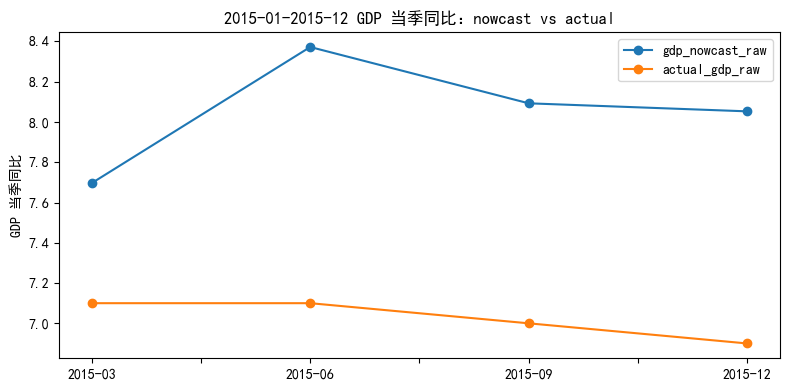

In [48]:
FORECAST_HORIZON_MONTHS = 12
FORECAST_START = TRAIN_END + 1
FORECAST_END = min(TRAIN_END + FORECAST_HORIZON_MONTHS, model_df_full.index.max())

if FORECAST_START > FORECAST_END:
    raise ValueError(f"训练窗口结束于 {TRAIN_END}，完整样本没有可用于窗口后预测的月份。")

forecast_raw_panel = model_df_full.loc[FORECAST_START:FORECAST_END, MODEL_COLS].copy()
forecast_winsorized_panel = forecast_raw_panel.copy()

# 窗口外预测期不能重新估计缩尾阈值，只能沿用训练期阈值，避免向前看。
for _, row in winsor_limits.dropna(subset=["lower_bound", "upper_bound"]).iterrows():
    col = row["variable"]
    if col in forecast_winsorized_panel.columns:
        forecast_winsorized_panel[col] = forecast_winsorized_panel[col].clip(
            lower=float(row["lower_bound"]),
            upper=float(row["upper_bound"]),
        )

forecast_z_panel = (forecast_winsorized_panel - mean_train) / std_train_safe
forecast_panel = pd.concat([z_model_df, forecast_z_panel.loc[:, z_model_df.columns]])
forecast_months = forecast_z_panel.index
forecast_panel.loc[forecast_months, GDP_COL] = np.nan

last_train_month = TRAIN_END
forecast_m0 = em_results["filter_results"]["filtered_state"].loc[last_train_month]
forecast_P0 = em_results["filter_results"]["filtered_cov"][last_train_month]

forecast_filter_results = run_kalman_filter_with_params(
    y_panel=forecast_panel,
    start=FORECAST_START,
    end=FORECAST_END,
    ar_params=em_results["ar_params"],
    loading_full=em_results["loading"],
    h_diag=em_results["h"],
    a1=forecast_m0,
    P1=forecast_P0,
)

forecast_state = forecast_filter_results["filtered_state"]
gdp_lambda_final = float(em_results["loading"].loc[GDP_COL])

gdp_nowcast_std = gdp_lambda_final * forecast_state["S_t"]
gdp_nowcast_raw = gdp_nowcast_std * gdp_std_train + gdp_mean_train

gdp_forecast_table = pd.DataFrame({
    "gdp_nowcast_std": gdp_nowcast_std,
    "gdp_nowcast_raw": gdp_nowcast_raw,
    "actual_gdp_raw": model_df_full.loc[FORECAST_START:FORECAST_END, GDP_COL],
    "actual_gdp_std": ((model_df_full.loc[FORECAST_START:FORECAST_END, GDP_COL] - mean_train[GDP_COL]) / std_train_safe[GDP_COL]),
})
gdp_forecast_table["is_quarter_end"] = [is_quarter_end_month(month) for month in gdp_forecast_table.index]
gdp_forecast_quarter_end = gdp_forecast_table.loc[gdp_forecast_table["is_quarter_end"]].copy()
gdp_forecast_quarter_end["forecast_error_raw"] = (
    gdp_forecast_quarter_end["gdp_nowcast_raw"] - gdp_forecast_quarter_end["actual_gdp_raw"]
)

display(gdp_forecast_quarter_end)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = gdp_forecast_quarter_end[["gdp_nowcast_raw", "actual_gdp_raw"]]
plot_df.index = plot_df.index.astype(str)
plot_df.plot(ax=ax, marker="o")
ax.set_title(f"{FORECAST_START}-{FORECAST_END} GDP 当季同比：nowcast vs actual")
ax.set_xlabel("")
ax.set_ylabel("GDP 当季同比")
plt.tight_layout()
plt.show()



## 16. 经济状态因子展示

本节使用最终 EM 参数下的 Kalman smoother 结果，展示训练窗口内月度经济状态因子：

$$
\hat{\alpha}_t = E(\alpha_t \mid Y)
$$

该因子已经在标准化变量空间中估计，因此数值本身没有 GDP 同比的单位；主要看方向、相对高低和周期变化。










,value
start,2005-01
end,2014-12
mean,0.0
std,1.338324
min,-3.000479
max,2.519836


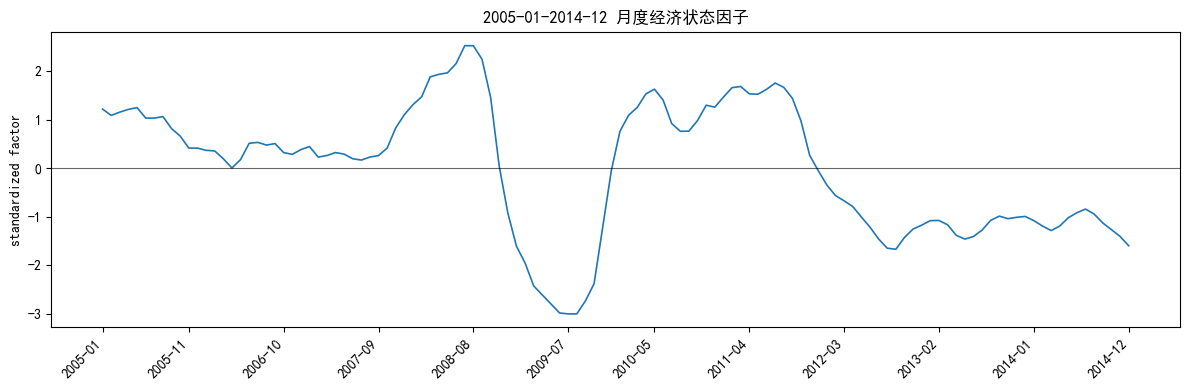

,annual_mean_factor
year,
2005,0.943790
2006,0.341433
2007,0.393883
2008,1.545902
2009,-2.229281
2010,1.134809
2011,1.291633
2012,-1.102632
2013,-1.163306


In [49]:
final_smoothed_state = em_results["smoother_results"]["smoothed_state"].copy()
economic_state_factor = final_smoothed_state["alpha_t"].rename("economic_state_factor")

factor_summary = pd.Series({
    "start": str(economic_state_factor.index.min()),
    "end": str(economic_state_factor.index.max()),
    "mean": economic_state_factor.mean(),
    "std": economic_state_factor.std(ddof=0),
    "min": economic_state_factor.min(),
    "max": economic_state_factor.max(),
})

display(factor_summary.to_frame("value"))

fig, ax = plt.subplots(figsize=(12, 4))
plot_index = economic_state_factor.index.astype(str)
ax.plot(plot_index, economic_state_factor, linewidth=1.2, color="#1f77b4")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)

tick_positions = np.linspace(0, len(plot_index) - 1, 12, dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([plot_index[i] for i in tick_positions], rotation=45, ha="right")
ax.set_title(f"{TRAIN_START}-{TRAIN_END} 月度经济状态因子")
ax.set_xlabel("")
ax.set_ylabel("standardized factor")
plt.tight_layout()
plt.show()

factor_by_year = (
    economic_state_factor
    .to_frame()
    .assign(year=lambda df: df.index.year)
    .groupby("year")["economic_state_factor"]
    .mean()
    .to_frame("annual_mean_factor")
)

display(factor_by_year)


## 17. 训练期 GDP 回测

本节使用最终 EM 参数下的 smoother 状态，对训练窗口内所有已观测的季度 GDP 做 in-sample fitted / backtest。

GDP 观测方程为：

$$
GDP_t^{std} = \lambda_{GDP} S_t + \varepsilon_{GDP,t}
$$

因此训练期拟合值为：

$$
\widehat{GDP}_t^{std} = \lambda_{GDP}\widehat{S}_t
$$

再反标准化回原始 GDP 同比单位：

$$
\widehat{GDP}_t
=
\widehat{GDP}_t^{std} \cdot std_{GDP,train}
+ mean_{GDP,train}
$$

这里只展示季度末且 GDP 有实际观测的月份。










,value
n_quarters,40.000000
mae_raw,1.716275
rmse_raw,2.014966
mean_error_raw,0.003073
corr_raw,0.485122


,gdp_fitted_std,gdp_fitted_raw,actual_gdp_raw,actual_gdp_std,is_quarter_end,fitted_error_raw,abs_error_raw,squared_error_raw
2005-03,0.472035,11.147669,11.2,0.494746,True,-0.052331,0.052331,0.002739
2005-06,0.422431,11.033370,11.1,0.451347,True,-0.066630,0.066630,0.004440
2005-09,0.352104,10.871324,10.9,0.364550,True,-0.028676,0.028676,0.000822
2005-12,0.180030,10.474828,12.4,1.015531,True,-1.925172,1.925172,3.706286
2006-03,0.110826,10.315368,12.4,1.015531,True,-2.084632,2.084632,4.345692
2006-06,0.083520,10.252447,13.6,1.536316,True,-3.347553,3.347553,11.206111
2006-09,0.183023,10.481724,12.2,0.928733,True,-1.718276,1.718276,2.952472
2006-12,0.119431,10.335194,12.5,1.058930,True,-2.164806,2.164806,4.686386


,gdp_fitted_std,gdp_fitted_raw,actual_gdp_raw,actual_gdp_std,is_quarter_end,fitted_error_raw,abs_error_raw,squared_error_raw
2013-03,-0.403153,9.131050,7.9,-0.937413,True,1.231050,1.231050,1.515484
2013-06,-0.515375,8.872466,7.6,-1.067609,True,1.272466,1.272466,1.619170
2013-09,-0.404649,9.127603,7.9,-0.937413,True,1.227603,1.227603,1.507010
2013-12,-0.369485,9.208627,7.7,-1.024211,True,1.508627,1.508627,2.275954
2014-03,-0.431279,9.066240,7.6,-1.067609,True,1.466240,1.466240,2.149861
2014-06,-0.379579,9.185370,7.7,-1.024211,True,1.485370,1.485370,2.206323
2014-09,-0.353858,9.244636,7.3,-1.197806,True,1.944636,1.944636,3.781611
2014-12,-0.517650,8.867224,7.4,-1.154407,True,1.467224,1.467224,2.152746


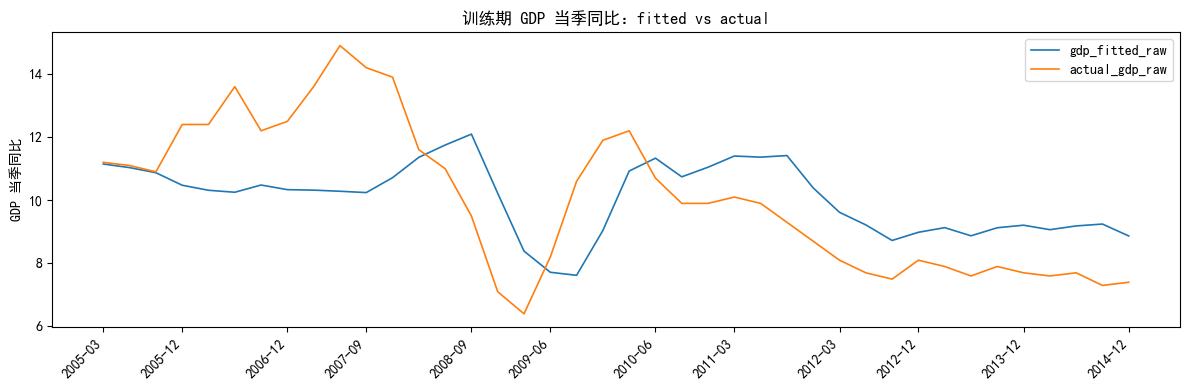

In [50]:
train_smoothed_state = em_results["smoother_results"]["smoothed_state"].copy()
gdp_lambda_final = float(em_results["loading"].loc[GDP_COL])

train_gdp_fitted_std_all = gdp_lambda_final * train_smoothed_state["S_t"]
train_gdp_fitted_raw_all = train_gdp_fitted_std_all * gdp_std_train + gdp_mean_train

train_gdp_backtest = pd.DataFrame({
    "gdp_fitted_std": train_gdp_fitted_std_all,
    "gdp_fitted_raw": train_gdp_fitted_raw_all,
    "actual_gdp_raw": model_df.loc[TRAIN_START:TRAIN_END, GDP_COL],
    "actual_gdp_std": z_model_df.loc[TRAIN_START:TRAIN_END, GDP_COL],
})
train_gdp_backtest["is_quarter_end"] = [is_quarter_end_month(month) for month in train_gdp_backtest.index]
train_gdp_backtest = train_gdp_backtest.loc[
    train_gdp_backtest["is_quarter_end"] & train_gdp_backtest["actual_gdp_raw"].notna()
].copy()

train_gdp_backtest["fitted_error_raw"] = (
    train_gdp_backtest["gdp_fitted_raw"] - train_gdp_backtest["actual_gdp_raw"]
)
train_gdp_backtest["abs_error_raw"] = train_gdp_backtest["fitted_error_raw"].abs()
train_gdp_backtest["squared_error_raw"] = train_gdp_backtest["fitted_error_raw"] ** 2

train_gdp_backtest_metrics = pd.Series({
    "n_quarters": len(train_gdp_backtest),
    "mae_raw": train_gdp_backtest["abs_error_raw"].mean(),
    "rmse_raw": np.sqrt(train_gdp_backtest["squared_error_raw"].mean()),
    "mean_error_raw": train_gdp_backtest["fitted_error_raw"].mean(),
    "corr_raw": train_gdp_backtest[["gdp_fitted_raw", "actual_gdp_raw"]].corr().iloc[0, 1],
})

display(train_gdp_backtest_metrics.to_frame("value"))
display(train_gdp_backtest.head(8))
display(train_gdp_backtest.tail(8))

fig, ax = plt.subplots(figsize=(12, 4))
plot_df = train_gdp_backtest[["gdp_fitted_raw", "actual_gdp_raw"]].copy()
plot_df.index = plot_df.index.astype(str)
plot_df.plot(ax=ax, linewidth=1.2)
tick_positions = np.linspace(0, len(plot_df.index) - 1, 12, dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([plot_df.index[i] for i in tick_positions], rotation=45, ha="right")
ax.set_title("训练期 GDP 当季同比：fitted vs actual")
ax.set_xlabel("")
ax.set_ylabel("GDP 当季同比")
plt.tight_layout()
plt.show()






